In [22]:
import numpy as np

date = "251128"
dl_folder = f"D:/Python_TK_3/datas/{date}_DL"

dl_number = "Vis_angle_multi_01"

look_frame = 30
models = 5

In [15]:
import tqdm
import os

shap_vals = []
bases = []
first_positives = []
for n in tqdm.tqdm(range(5)):
    # 保存先ディレクトリを作成
    model_dir = os.path.join(os.path.join(dl_folder, f"model_{dl_number}"), f"model_{n}")

    shap_val = np.load((f"{model_dir}/{date}_{dl_number}_shap_val.npy"))
    base     = np.load((f"{model_dir}/{date}_{dl_number}_shap_base.npy"))

    print(shap_val.shape)

    shap_vals.append(shap_val)
    bases.append(base)

    first_positive = np.load(f"{model_dir}/{date}_{dl_number}_valid_1st_positive_frames.npy")
    first_positives.append(first_positive)

#shap_vals = np.array(shap_vals)
bases     = np.array(bases)

print(len(shap_vals), bases.shape)
print(len(first_positives), first_positives[0].shape, first_positives[1].shape, first_positives[2].shape)

100%|██████████| 5/5 [00:00<00:00, 33.42it/s]

(1350, 31, 23)
(1400, 31, 23)
(1400, 31, 23)
(1500, 31, 23)
(1500, 31, 23)
5 (5,)
5 (16,) (27,) (17,)


In [16]:
valid_ex = []
for n in range(len(first_positives)):
    temp_ex = []
    for f in range(first_positives[n].shape[0]):
        temp_ex.append(first_positives[n][f]//80)
    valid_ex.append(np.array(temp_ex))

print(len(valid_ex), valid_ex[0].shape, valid_ex[1].shape, valid_ex[2].shape)

5 (16,) (27,) (17,)


In [17]:
first_shaps = []
mean_shaps = []
for n in tqdm.tqdm(range(len(first_positives))):
    first_shap = shap_vals[n][first_positives[n]]
    first_shaps.append(first_shap)

    mean_shap = np.mean(first_shap, axis=0)
    mean_shaps.append(mean_shap)

mean_shaps = np.array(mean_shaps)

print(len(first_shaps), first_shaps[0].shape, first_shaps[1].shape, first_shaps[2].shape)
print(mean_shaps.shape)

100%|██████████| 5/5 [00:00<00:00, 1620.42it/s]

5 (16, 31, 23) (27, 31, 23) (17, 31, 23)
(5, 31, 23)


In [23]:
fs = 20

# 初期値
start_value = -1.5

# 増加量
increment = 1/fs

# 繰り返し回数
count = look_frame+1

# リストを生成
t = [start_value + i * increment for i in range(count)]

In [24]:
roi_number = []
for ic in range(mean_shaps.shape[2]):
    roi_number.append(f"IC{ic+1}")

print(roi_number)

['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'IC6', 'IC7', 'IC8', 'IC9', 'IC10', 'IC11', 'IC12', 'IC13', 'IC14', 'IC15', 'IC16', 'IC17', 'IC18', 'IC19', 'IC20', 'IC21', 'IC22', 'IC23']


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

def show_shap_abs_mean(shap_val):
    s = np.mean(np.abs(shap_val), axis=0).reshape([look_frame+1, shap_val.shape[2]])
    plt.figure(figsize=(6, 6))
    sns.heatmap(s.transpose(),cmap='viridis')
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
    # Tickの位置
    ticks = np.arange(0.5, look_frame + 1.0, 5)
    # 同じ数のラベルを作る
    labels = np.linspace(start_value, 0, len(ticks))
    plt.xticks(ticks, labels)
    plt.yticks( np.arange(0.5, shap_val.shape[2]+0.5), roi_number, rotation=0)
    plt.axvspan(20.45, 20.55, color='red', alpha=1)
    plt.title("Absolute SHAP values")
    plt.xlabel("Time (s)")
    plt.ylabel("Component #")
    plt.show()

In [8]:
#for model in range(mean_shaps.shape[0]):
#    show_shap_abs_mean(mean_shaps[model].reshape(1, mean_shaps.shape[1], mean_shaps.shape[2]))

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

def show_shap_mean(shap_val):
    s = np.mean(shap_val, axis=0).reshape([look_frame+1, shap_val.shape[2]])
    plt.figure(figsize=(4, 4))
    sns.heatmap(s.transpose(),cmap='bwr', vmin=-0.002, vmax=0.002)
    #sns.heatmap(s.transpose(),cmap='bwr')
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
    # Tickの位置
    ticks = np.arange(0.5, look_frame + 1.0, 10)
    # 同じ数のラベルを作る
    labels = np.linspace(start_value, 0, len(ticks))
    plt.xticks(ticks, labels, rotation=0)
    plt.yticks( np.arange(0.5, shap_val.shape[2]+0.5), roi_number, rotation=0)
    plt.axvspan(30.45, 30.55, color='black', alpha=1)
    plt.title("SHAP values")
    plt.xlabel("Time (sec)")
    plt.ylabel("IC #")
    #plt.colorbar('off')
    plt.show()

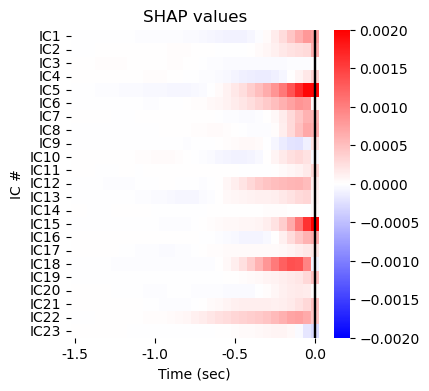

In [38]:
show_shap_mean(np.mean(mean_shaps, axis=0).reshape(1, mean_shaps.shape[1], mean_shaps.shape[2]))

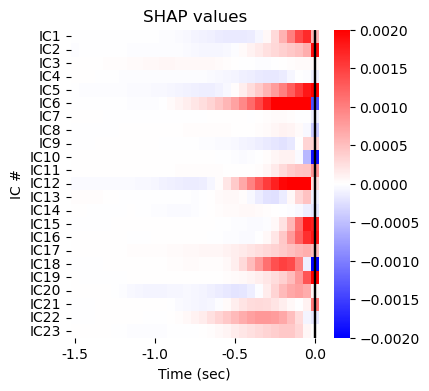

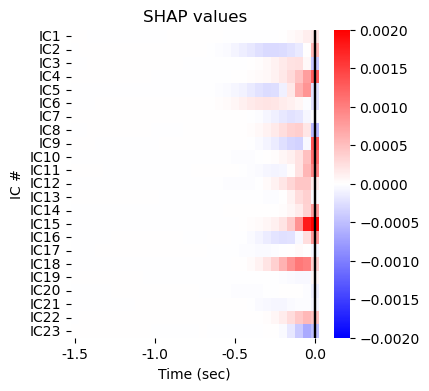

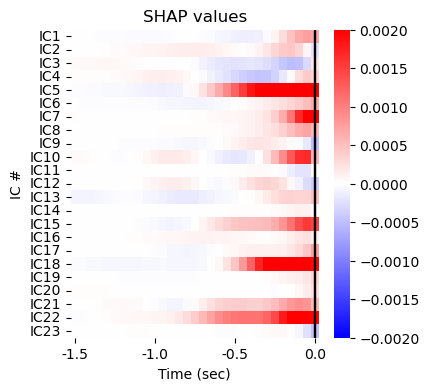

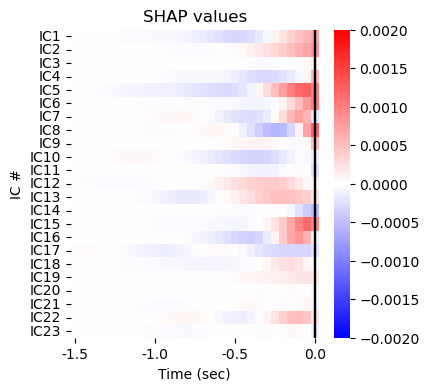

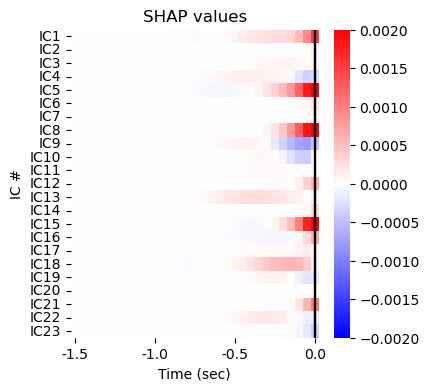

In [39]:
for model in range(mean_shaps.shape[0]):
    show_shap_mean(mean_shaps[model].reshape(1, mean_shaps.shape[1], mean_shaps.shape[2]))

In [40]:
np.save(f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_mean_shap_ic.npy", mean_shaps)

In [13]:
mean_array = np.load(f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_means.npy")
std_array = np.load(f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_stds.npy")
min_array = np.load(f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_mins.npy")
max_array = np.load(f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_maxs.npy")

print(mean_array.shape, std_array.shape, min_array.shape, max_array.shape)

(3, 12, 6) (3, 12, 6) (3, 12, 6) (3, 12, 6)


In [14]:
mean_list, std_list, min_list, max_list = [], [], [], []
for mouse in range(3):
    mean_list.append(mean_array[mouse][valid_ex[mouse]])
    std_list.append(std_array[mouse][valid_ex[mouse]])
    min_list.append(min_array[mouse][valid_ex[mouse]])
    max_list.append(max_array[mouse][valid_ex[mouse]])

print(len(mean_list), mean_list[0].shape, mean_list[1].shape, mean_list[2].shape)

3 (6, 6) (6, 6) (6, 6)


In [41]:
from wfield import *

def my_reconstruct(u,svt,dims = None):
    '''
    Reconstruct a decomposed signal (e.g. decomposed with SVD for example).

    Can also reconstruct sparse arrays, use dims when reconstructing sparse.

    Usage:
        res = reconstruct(u,svt,dims = None)
    
    Joao Couto - wfield, 2020
    '''
    if issparse(u):
        if dims is None:
            raise ValueError('Supply dims = [H,W] when using sparse arrays')
    else:
        if dims is None:
            dims = u.shape[:2]
            
    return np.matmul(u, svt).reshape((*dims,-1)).transpose(-1,0,1).squeeze()

In [42]:
U = np.load("D:/Python_TK_3/datas/251110_ica/250829-251031_vis_angle_v8/ic_image_extracted.npy")
print(U.shape)

(23, 256, 270)


In [43]:
U = U.transpose(1, 2, 0)
print(U.shape)

(256, 270, 23)


In [44]:
use_comp = first_shaps[0].shape[2]

mov_array = []
for model in range(len(first_shaps)):
    mov = []
    for ex in range(first_shaps[model].shape[0]):
    #for ex in range(1):
        #norm_shap = first_shaps[model][ex]
        #for comp in range(first_shaps[model].shape[2]):
        #    norm_shap[:, comp] = norm_shap[:, comp] / ((max_list[model][ex, comp]-min_list[model][ex, comp])*std_list[model][ex, comp])
        #temp_mov = my_reconstruct(U[:, :,:use_comp], norm_shap.transpose())
        temp_mov = my_reconstruct(U[:, :,:use_comp], first_shaps[model][ex].transpose())
        mov.append(temp_mov)
    mov_array.append(np.array(mov))

print(len(mov_array), mov_array[0].shape, mov_array[1].shape, mov_array[2].shape)

5 (16, 31, 256, 270) (27, 31, 256, 270) (17, 31, 256, 270)


In [45]:
ave_mov = []
for model in range(len(mov_array)):
    temp_ave = np.mean(mov_array[model], axis=0)
    ave_mov.append(temp_ave)

ave_mov = np.array(ave_mov)
print(ave_mov.shape)

(5, 31, 256, 270)


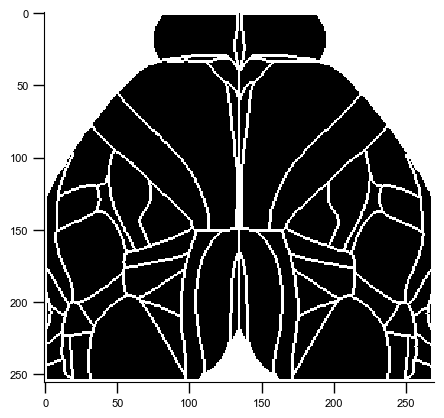

In [46]:
import numpy as np
import matplotlib.pyplot as plt

atlas_map = np.load("D:/Python_TK_3/datas/brain_map/region_border_masked.npy")
plt.imshow(atlas_map, cmap='grey')

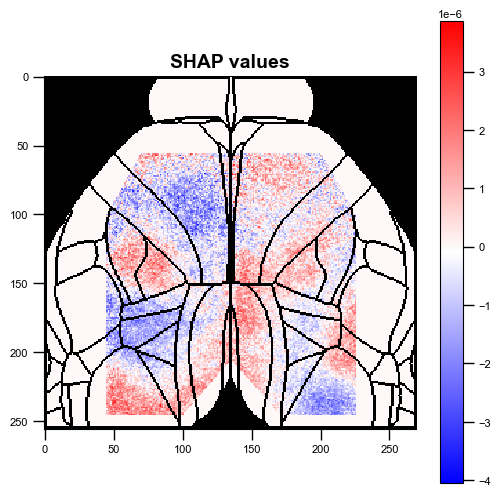

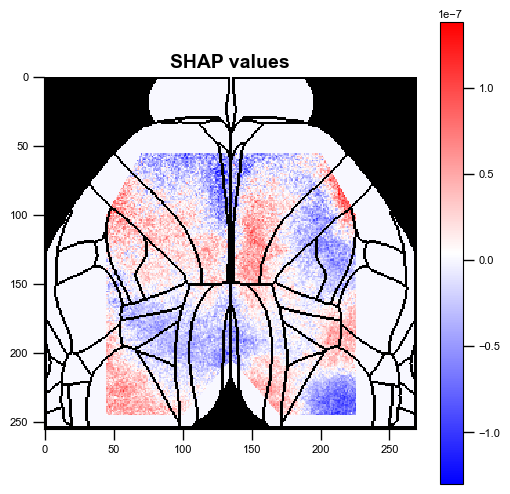

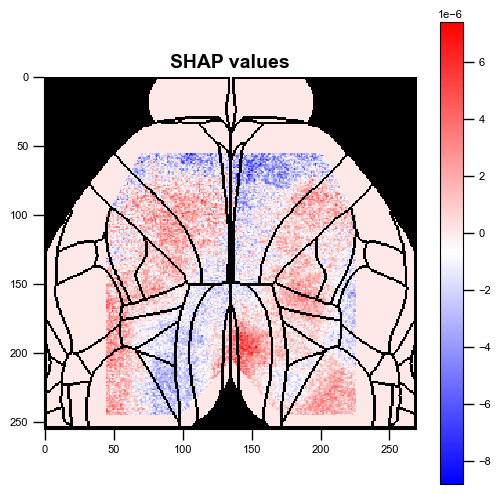

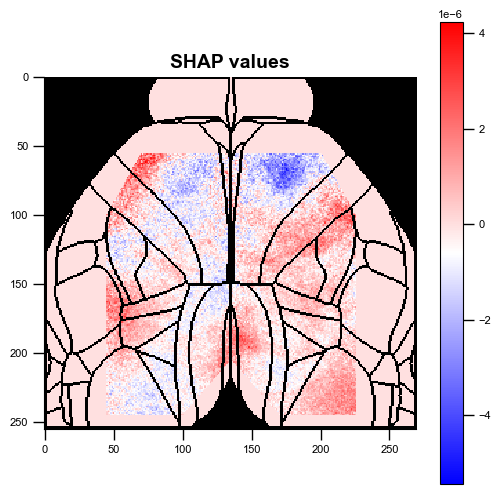

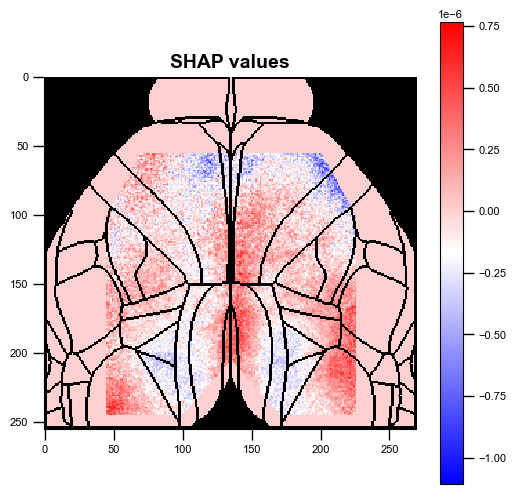

In [47]:
import matplotlib.pyplot as plt

for model in range(ave_mov.shape[0]):
    plt.figure(figsize=(6, 6))
    mask = atlas_map
    masked = np.ma.masked_where(mask == 1, np.mean(ave_mov[model, 10:14], axis=0))
    cmap = plt.cm.bwr.copy()
    cmap.set_bad(color='black')  # マスクされた部分を白で表示
    plt.imshow(masked, cmap=cmap)
    plt.colorbar()
    plt.title("SHAP values")
    plt.show()

In [71]:
vmin, vmax=-5e-5, +5e-5
#vmin, vmax=-0.0001, +0.0001

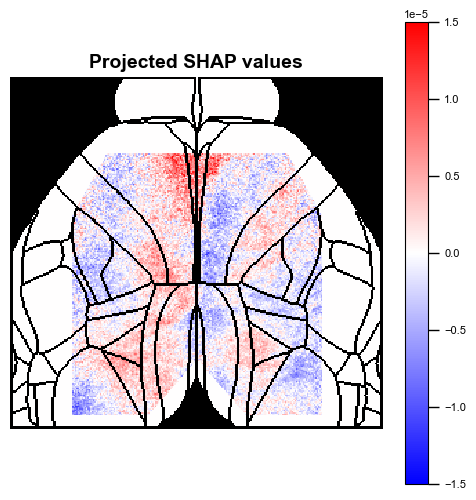

In [51]:
import matplotlib.pyplot as plt

common_shap = np.mean(ave_mov, axis=0)
plt.figure(figsize=(6, 6))
mask = atlas_map
masked = np.ma.masked_where(mask == 1, np.mean(common_shap, axis=0))
cmap = plt.cm.bwr.copy()
cmap.set_bad(color='black')  # マスクされた部分を白で表示
plt.imshow(masked, cmap=cmap, vmin=-1.5e-5, vmax=+1.5e-5)
#plt.imshow(masked, cmap=cmap)
plt.colorbar()
plt.title("Projected SHAP values")
plt.axis('off')
plt.show()

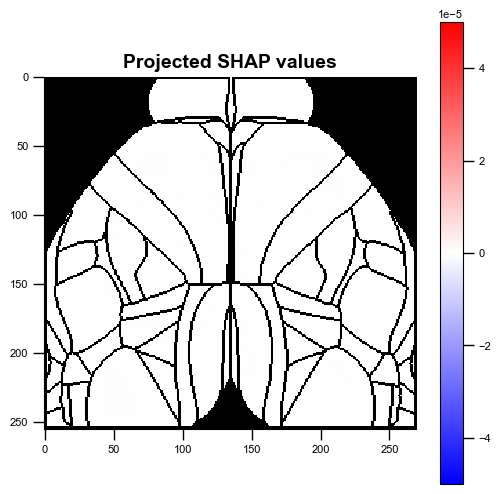

In [72]:
import matplotlib.pyplot as plt

common_shap = np.mean(ave_mov, axis=0)
plt.figure(figsize=(6, 6))
mask = atlas_map
masked = np.ma.masked_where(mask == 1, np.mean(common_shap[:2], axis=0))
cmap = plt.cm.bwr.copy()
cmap.set_bad(color='black')  # マスクされた部分を白で表示
plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
#plt.imshow(masked, cmap=cmap)
plt.colorbar()
plt.title("Projected SHAP values")
plt.show()

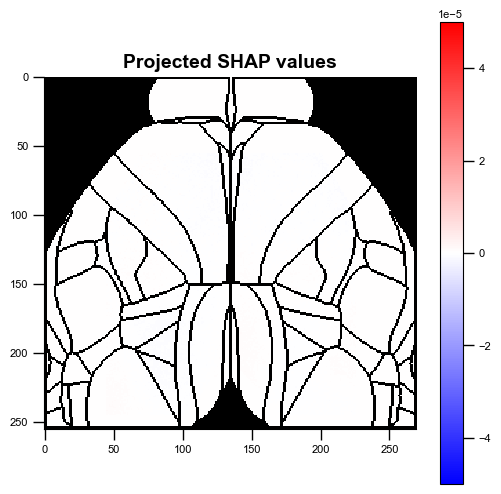

In [73]:
import matplotlib.pyplot as plt

common_shap = np.mean(ave_mov, axis=0)
plt.figure(figsize=(6, 6))
mask = atlas_map
masked = np.ma.masked_where(mask == 1, np.mean(common_shap[:10], axis=0))
cmap = plt.cm.bwr.copy()
cmap.set_bad(color='black')  # マスクされた部分を白で表示
plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
#plt.imshow(masked, cmap=cmap)
plt.colorbar()
plt.title("Projected SHAP values")
plt.show()

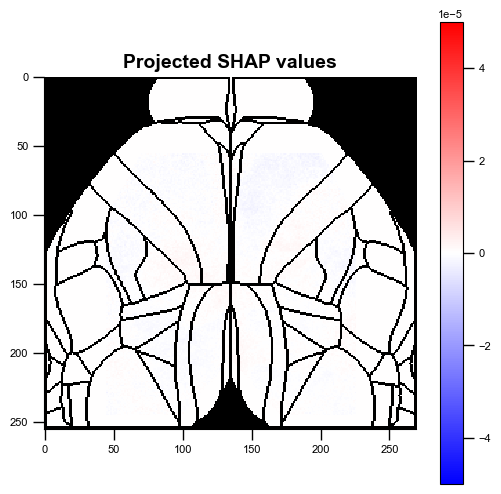

In [75]:
import matplotlib.pyplot as plt

common_shap = np.mean(ave_mov, axis=0)
plt.figure(figsize=(6, 6))
mask = atlas_map
masked = np.ma.masked_where(mask == 1, np.mean(common_shap[10:20], axis=0))
cmap = plt.cm.bwr.copy()
cmap.set_bad(color='black')  # マスクされた部分を白で表示
plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
#plt.imshow(masked, cmap=cmap)
plt.colorbar()
plt.title("Projected SHAP values")
plt.show()

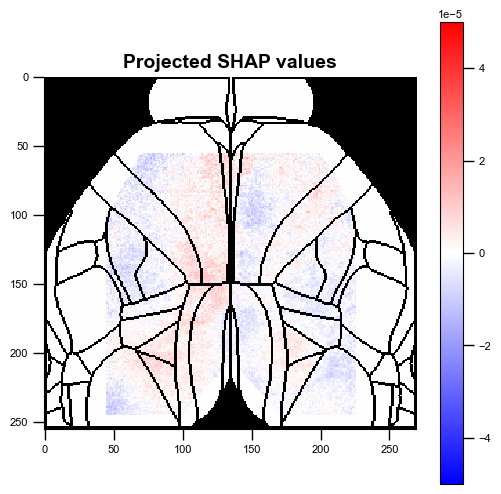

In [76]:
import matplotlib.pyplot as plt

common_shap = np.mean(ave_mov, axis=0)
plt.figure(figsize=(6, 6))
mask = atlas_map
masked = np.ma.masked_where(mask == 1, np.mean(common_shap[20:24], axis=0))
cmap = plt.cm.bwr.copy()
cmap.set_bad(color='black')  # マスクされた部分を白で表示
plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
#plt.imshow(masked, cmap=cmap)
plt.colorbar()
plt.title("Projected SHAP values")
plt.show()

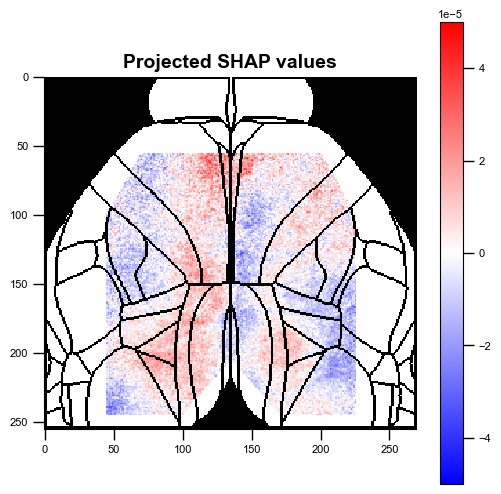

In [77]:
import matplotlib.pyplot as plt

common_shap = np.mean(ave_mov, axis=0)
plt.figure(figsize=(6, 6))
mask = atlas_map
masked = np.ma.masked_where(mask == 1, np.mean(common_shap[24:28], axis=0))
cmap = plt.cm.bwr.copy()
cmap.set_bad(color='black')  # マスクされた部分を白で表示
plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
#plt.imshow(masked, cmap=cmap)
plt.colorbar()
plt.title("Projected SHAP values")
plt.show()

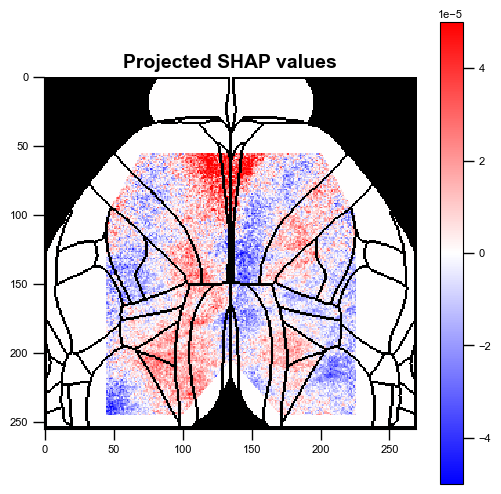

In [78]:
import matplotlib.pyplot as plt

common_shap = np.mean(ave_mov, axis=0)
plt.figure(figsize=(6, 6))
mask = atlas_map
masked = np.ma.masked_where(mask == 1, np.mean(common_shap[28:30], axis=0))
cmap = plt.cm.bwr.copy()
cmap.set_bad(color='black')  # マスクされた部分を白で表示
plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
#plt.imshow(masked, cmap=cmap)
plt.colorbar()
plt.title("Projected SHAP values")
plt.show()

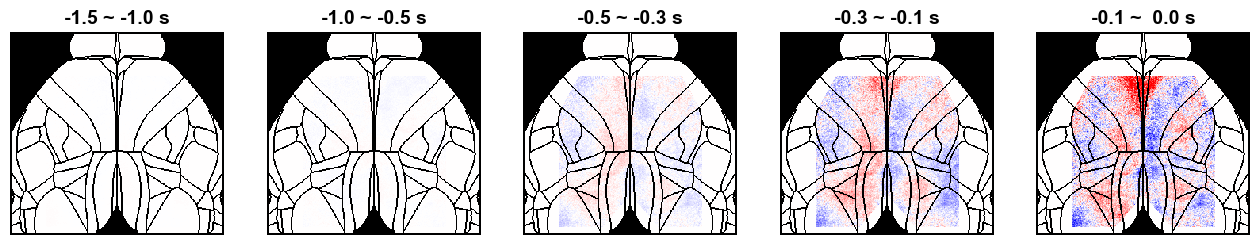

In [102]:
import matplotlib.pyplot as plt

common_shap = np.mean(ave_mov, axis=0)
shap_map = [
            np.mean(common_shap[0:10], axis=0),
            np.mean(common_shap[10:20], axis=0),
            np.mean(common_shap[20:24], axis=0),
            np.mean(common_shap[24:28], axis=0),
            np.mean(common_shap[28:], axis=0),
            ]

time_list = [
            "-1.5 ~ -1.0 s",
            "-1.0 ~ -0.5 s",
            "-0.5 ~ -0.3 s",
            "-0.3 ~ -0.1 s",
            "-0.1 ~  0.0 s",
            ]


plt.figure(figsize=(16, 4))
mask = atlas_map
for shapmap in range(len(shap_map)):
    plt.subplot(1, 5, shapmap+1)
    masked = np.ma.masked_where(mask == 1, shap_map[shapmap])
    cmap = plt.cm.bwr.copy()
    cmap.set_bad(color='black')  # マスクされた部分を白で表示
    plt.title(time_list[shapmap])
    plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.axis('off')

#plt.imshow(masked, cmap=cmap)
#plt.colorbar()
#plt.title("Projected SHAP values")
plt.show()

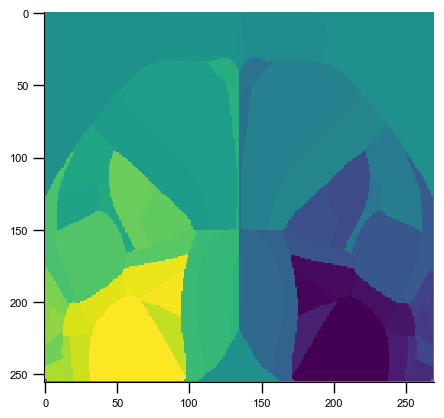

In [80]:
atlas = np.load("D:/Python_TK_3/datas/brain_map/atlas.npy").astype(int)
plt.imshow(atlas)

In [81]:
import tqdm

# 一意の値ごとにROIを作成
unique_values = np.unique(atlas)
roi_means = []
roi_positions = []

for val in tqdm.tqdm(unique_values):
    mask = (atlas == val)  # 該当する値のROIを作成
    if np.sum(mask) > 0:  # ROIが存在する場合のみ
        # ROIの代表位置 (マスクの重心)
        y_indices, x_indices = np.where(mask)
        center_x, center_y = int(np.mean(x_indices)), int(np.mean(y_indices))
        roi_positions.append((center_x, center_y, val))  # x, y, ラベル
        temp_roi_means = []
        for ex in range(len(ave_mov)):
            temp_mov = ave_mov[ex]
            mean_values = np.mean(temp_mov[:, mask], axis=1)  # ROI領域の平均を時間ごとに計算
            temp_roi_means.append(mean_values)
        roi_means.append(temp_roi_means)



# numpy 配列に変換 (ROI数, 時間)
roi_means_array = np.array(roi_means)

100%|██████████| 61/61 [00:00<00:00, 492.77it/s]


In [82]:
print(roi_means_array.shape)

(61, 5, 31)


In [83]:
roi_means_array = roi_means_array.reshape(roi_means_array.shape[0], roi_means_array.shape[1]*roi_means_array.shape[2])
print(roi_means_array.shape)

(61, 155)


In [84]:
#frames = fs*(end_reconst-start_reconst)

indices_to_left = [-33,-32,-31,-27,-18,-17,-16,-12,-11,-10,-9,-4,-3,
                   3,4,9,10,11,12,16,17,18,27,31,32,33]

# indices_to_leftの各値に33を加算
index_left = [index for index, value in enumerate(unique_values.tolist()) if value in indices_to_left]

print(index_left)
print(len(indices_to_left))  # 28が出力されるはず

[0, 1, 2, 6, 13, 14, 15, 18, 19, 20, 21, 26, 27, 33, 34, 39, 40, 41, 42, 45, 46, 47, 54, 58, 59, 60]
26


In [85]:
roi_numbers = []
roi_traces = []
for j, i in enumerate(index_left):
    roi_numbers.append(unique_values[i])
    roi_traces.append(roi_means_array[i])

roi_numbers = np.array(roi_numbers)
roi_traces = np.array(roi_traces)

print(roi_numbers)
print(roi_numbers.shape)
print(roi_traces.shape)

[-33 -32 -31 -27 -18 -17 -16 -12 -11 -10  -9  -4  -3   3   4   9  10  11
  12  16  17  18  27  31  32  33]
(26,)
(26, 155)


In [86]:
roi_traces = roi_traces.reshape(roi_traces.shape[0], ave_mov.shape[0], int(roi_traces.shape[1]/ave_mov.shape[0]))
print(roi_traces.shape)

(26, 5, 31)


In [87]:
# 許可する文字
roi_names = np.array([' VISp_R  ', ' VISam_R ', ' VISa_R  ', ' VISpm_R ',
                 'SSp-ul_R ', 'SSp-ll_R ', 'SSp-tr_R ',
                 'RSPagl_R ', ' RSPd_R  ', ' RSPv_R  ',
                 ' ACAd_R  ',
                 '  MOs_R  ', '  MOp_R  ',
                 '  MOp_L  ', '  MOs_L  ',
                 ' ACAd_L  ',
                 ' RSPv_L  ', ' RSPd_L  ', 'RSPagl_L ',
                 'SSp-tr_L ', 'SSp-ll_L ', 'SSp-ul_L ',
                 ' VISpm_L ', ' VISa_L  ', ' VISam_L ', ' VISp_L  '
                 ])

print(roi_names.shape)

(26,)


In [89]:
fs = 20

# 初期値
start_value = -1.5

# 増加量
increment = 1/fs

# 繰り返し回数
count = look_frame+1

# リストを生成
t = [start_value + i * increment for i in range(count)]

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

def show_shap_roi_mean(roi_array, roi_names):
    s = np.mean(roi_array, axis=1)
    plt.figure(figsize=(4, 4))
    #sns.heatmap(s, cmap='bwr', vmin=-2e-5, vmax=2e-5)
    sns.heatmap(s, cmap='bwr', vmin=-0.00003, vmax=0.00003)
    #sns.heatmap(s, cmap='bwr')
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
    # Tickの位置
    ticks = np.arange(0.5, look_frame + 1.0, 10)
    # 同じ数のラベルを作る
    labels = np.linspace(start_value, 0, len(ticks))
    plt.xticks(ticks, labels)
    plt.yticks( np.arange(0.5, roi_array.shape[0]+0.5), roi_names, rotation=0)
    plt.axvspan(30.45, 30.55, color='black', alpha=1)
    #plt.axvspan(19.45, 19.55, color='black', alpha=1)
    plt.title("Projected SHAP values")
    plt.xlabel("Time (s)")
    #plt.ylabel("Component #")
    plt.show()

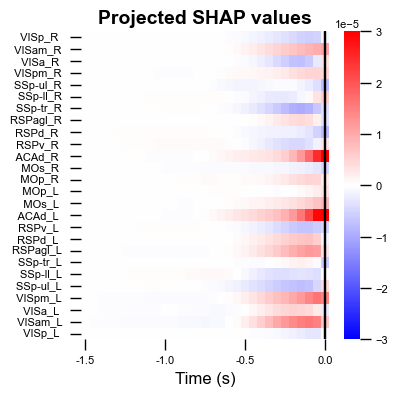

In [99]:
show_shap_roi_mean(roi_traces, roi_names)

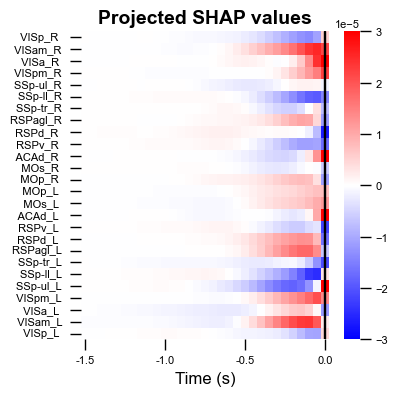

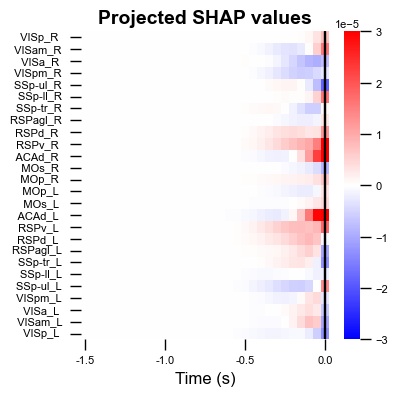

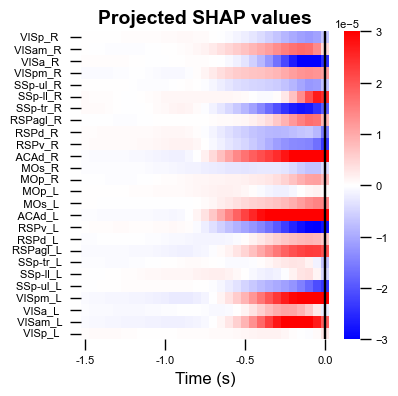

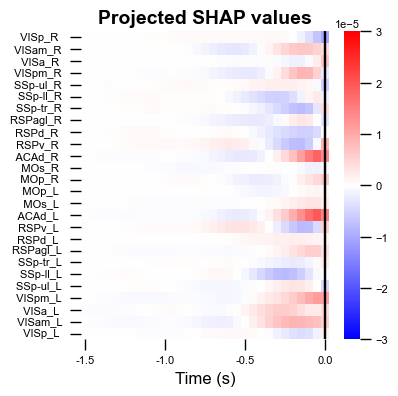

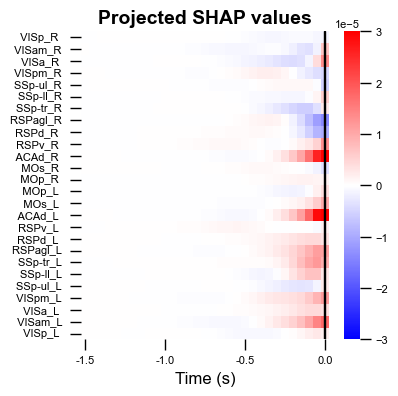

In [100]:
for model in range(roi_traces.shape[1]):
    show_shap_roi_mean(roi_traces[:, model].reshape(roi_traces.shape[0], 1, roi_traces.shape[2]), roi_names)

In [101]:
np.save(f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_mean_shap_allen.npy", roi_traces.transpose(1, 2, 0))

In [13]:
dl_1 = "Vis_angle_multi_04"
dl_2 = "Vis_angle_multi_01"
dl_3 = "Vis_angle_multi_03"
dl_4 = "Vis_angle_multi_05"
dl_5 = "Vis_angle_multi_06"

loss_1 = np.load(f"{dl_folder}/model_{dl_1}/{date}_{dl_1}_valid_loss_best.npy")
loss_2 = np.load(f"{dl_folder}/model_{dl_2}/{date}_{dl_2}_valid_loss_best.npy")
loss_3 = np.load(f"{dl_folder}/model_{dl_3}/{date}_{dl_3}_valid_loss_best.npy")
loss_4 = np.load(f"{dl_folder}/model_{dl_4}/{date}_{dl_4}_valid_loss_best.npy")
loss_5 = np.load(f"{dl_folder}/model_{dl_5}/{date}_{dl_5}_valid_loss_best.npy")



auc_1 = np.load(f"{dl_folder}/model_{dl_1}/{date}_{dl_1}_valid_auc_best.npy")
auc_2 = np.load(f"{dl_folder}/model_{dl_2}/{date}_{dl_2}_valid_auc_best.npy")
auc_3 = np.load(f"{dl_folder}/model_{dl_3}/{date}_{dl_3}_valid_auc_best.npy")
auc_4 = np.load(f"{dl_folder}/model_{dl_4}/{date}_{dl_4}_valid_auc_best.npy")
auc_5 = np.load(f"{dl_folder}/model_{dl_5}/{date}_{dl_5}_valid_auc_best.npy")

acc_1 = np.load(f"{dl_folder}/model_{dl_1}/{date}_{dl_1}_valid_accuracy_best.npy")
acc_2 = np.load(f"{dl_folder}/model_{dl_2}/{date}_{dl_2}_valid_accuracy_best.npy")
acc_3 = np.load(f"{dl_folder}/model_{dl_3}/{date}_{dl_3}_valid_accuracy_best.npy")
acc_4 = np.load(f"{dl_folder}/model_{dl_4}/{date}_{dl_4}_valid_accuracy_best.npy")
acc_5 = np.load(f"{dl_folder}/model_{dl_5}/{date}_{dl_5}_valid_accuracy_best.npy")
#acc_6 = np.load(f"{dl_folder}/model_{dl_6}/{date}_{dl_6}_valid_accuracy_best.npy")
#acc_7 = np.load(f"{dl_folder}/model_{dl_7}/{date}_{dl_7}_valid_accuracy_best.npy")

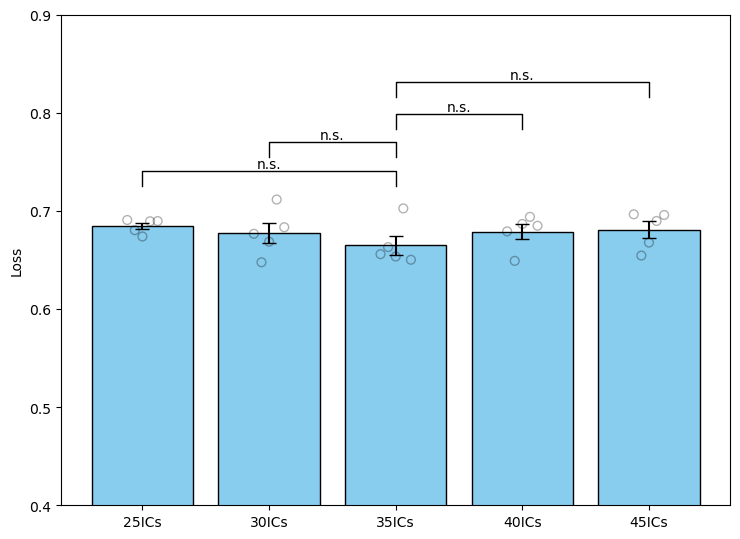

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ------- サンプルデータ（各n=5。ここを書き換えて使う） -------
data1 = loss_1
data2 = loss_2
data3 = loss_3  # 基準（3つ目）
#data4 = loss_4
#data5 = loss_5

datasets = [data1, data2, data3, data4, data5]
labels   = ["25ICs", "30ICs", "35ICs", "40ICs", "45ICs"]

# ------- 統計量（Mean ± SEM） -------
means = [np.mean(d) for d in datasets]
sems  = [np.std(d, ddof=1) / np.sqrt(len(d)) for d in datasets]

# ------- Wilcoxon rank-sum (Mann–Whitney U)：3つ目 vs 他4群 -------
control_idx = 2
pairs = [i for i in range(len(datasets)) if i != control_idx]  # [0,1,3,4]
p_raw = []
for i in pairs:
    # 独立2群・両側。小標本は exact、ties 等では近似を SciPy に自動選択させる
    stat, p = stats.mannwhitneyu(datasets[i], datasets[control_idx],
                                 alternative='two-sided', method='auto')
    p_raw.append(p)

# ------- Holm 補正 -------
reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')
p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}

def p_to_symbol(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ------- プロット -------
x = np.arange(len(datasets))
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# 棒（Mean ± SEM）
ax.bar(x, means, yerr=sems, capsize=5,
       color="#88ccee", edgecolor="black", ecolor="black", linewidth=1)

# 各データ点（薄い丸、少しジッター）
for i, d in enumerate(datasets):
    jitter = np.linspace(-0.12, 0.12, len(d))
    ax.scatter(np.full_like(d, x[i], dtype=float) + jitter, d,
               s=40, facecolors="none", edgecolors="black", alpha=0.3)

# 有意差ライン（3つ目 vs 他）。重ならないように段を上げる
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
base_offset = 0.05 * y_range    # 棒の上からの余白
step = 0.04 * y_range           # ラインを積み上げる間隔
line_h = 0.02 * y_range

# 段を割り当て（左からの距離で重ならないよう工夫してもOK。ここは単純に順に上げる）
for k, i in enumerate(pairs):
    p = p_holm[i]
    sym = p_to_symbol(p)
    x1, x2 = i, control_idx
    # 比較2本の棒の高い方の上に段差を加える
    y = max(means[i] + sems[i], means[control_idx] + sems[control_idx]) + base_offset + k*step

    # コの字ライン
    ax.plot([x1, x1, x2, x2], [y, y + line_h, y + line_h, y],
            color="black", linewidth=1)

    # 中央に星・n.s.
    ax.text((x1 + x2) / 2, y + line_h, sym, ha="center", va="bottom")

# 体裁
ax.set_ylim(0.4, 0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Loss")
#ax.set_title("Mean ± SEM (Wilcoxon rank-sum vs 3rd, Holm-corrected)")
plt.tight_layout()
plt.show()


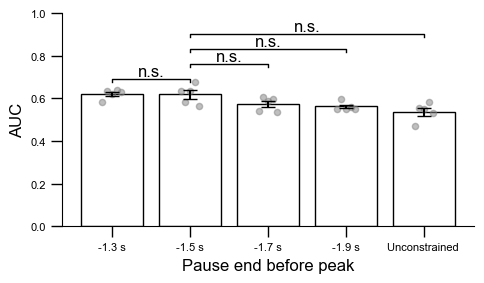

[1.0, 0.4444444444444444, 0.09523809523809523, 0.06349206349206349]


In [118]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ------- サンプルデータ（各n=5。ここを書き換えて使う） -------
data1 = auc_1
data2 = auc_2
data3 = auc_3  # 基準（3つ目）
data4 = auc_4
data5 = auc_5

datasets = [data1, data2, data3, data4, data5]
labels   = ["-1.3 s", "-1.5 s", "-1.7 s", "-1.9 s", "Unconstrained "]

# ------- 統計量（Mean ± SEM） -------
means = [np.mean(d) for d in datasets]
sems  = [np.std(d, ddof=1) / np.sqrt(len(d)) for d in datasets]

# ------- Wilcoxon rank-sum (Mann–Whitney U)：3つ目 vs 他4群 -------
control_idx = 1
pairs = [i for i in range(len(datasets)) if i != control_idx]  # [0,1,3,4]
p_raw = []
for i in pairs:
    # 独立2群・両側。小標本は exact、ties 等では近似を SciPy に自動選択させる
    stat, p = stats.mannwhitneyu(datasets[i], datasets[control_idx],
                                 alternative='two-sided', method='auto')
    p_raw.append(p)

# ------- Holm 補正 -------
reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')
p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}

def p_to_symbol(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ------- プロット -------
x = np.arange(len(datasets))
fig, ax = plt.subplots(figsize=(5, 3))

# 棒（Mean ± SEM）
ax.bar(x, means, yerr=sems, capsize=5,
       color="white", edgecolor="black", ecolor="black", linewidth=1)

# 各データ点（薄い丸、少しジッター）
for i, d in enumerate(datasets):
    jitter = np.linspace(-0.12, 0.12, len(d))
    ax.scatter(np.full_like(d, x[i], dtype=float) + jitter, d,
               s=20, facecolors="gray", edgecolors="gray", alpha=0.5)

# 有意差ライン（3つ目 vs 他）。重ならないように段を上げる
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
base_offset = 0.05 * y_range    # 棒の上からの余白
step = 0.10 * y_range           # ラインを積み上げる間隔
line_h = 0.02 * y_range

ps = []
# 段を割り当て（左からの距離で重ならないよう工夫してもOK。ここは単純に順に上げる）
for k, i in enumerate(pairs):
    p = p_holm[i]
    ps.append(p)
    sym = p_to_symbol(p)
    x1, x2 = i, control_idx
    # 比較2本の棒の高い方の上に段差を加える
    y = max(means[i] + sems[i], means[control_idx] + sems[control_idx]) + base_offset + k*step

    # コの字ライン
    ax.plot([x1, x1, x2, x2], [y, y + line_h, y + line_h, y],
            color="black", linewidth=1)

    # 中央に星・n.s.
    ax.text((x1 + x2) / 2, y + line_h, sym, ha="center", va="bottom")

# 体裁
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("AUC")
ax.set_xlabel("Pause end before peak")
plt.tight_layout()
plt.show()

print(ps)


In [104]:
ex_1 = np.load(f"{dl_folder}/model_{dl_1}/{date}_{dl_1}_ex_rate.npy")
ex_2 = np.load(f"{dl_folder}/model_{dl_2}/{date}_{dl_2}_ex_rate.npy")
ex_3 = np.load(f"{dl_folder}/model_{dl_3}/{date}_{dl_3}_ex_rate.npy")
ex_4 = np.load(f"{dl_folder}/model_{dl_4}/{date}_{dl_4}_ex_rate.npy")
ex_5 = np.load(f"{dl_folder}/model_{dl_5}/{date}_{dl_5}_ex_rate.npy")



po_1 = np.load(f"{dl_folder}/model_{dl_1}/{date}_{dl_1}_positive_rate.npy")
po_2 = np.load(f"{dl_folder}/model_{dl_2}/{date}_{dl_2}_positive_rate.npy")
po_3 = np.load(f"{dl_folder}/model_{dl_3}/{date}_{dl_3}_positive_rate.npy")
po_4 = np.load(f"{dl_folder}/model_{dl_4}/{date}_{dl_4}_positive_rate.npy")
po_5 = np.load(f"{dl_folder}/model_{dl_5}/{date}_{dl_5}_positive_rate.npy")

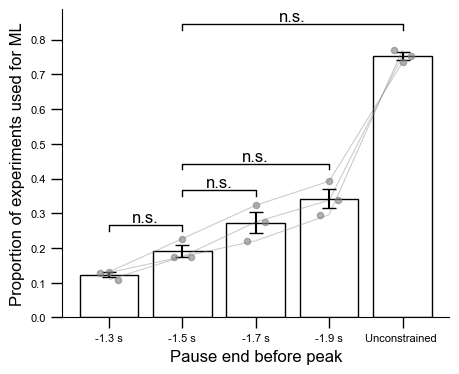

[1.0, 1.0, 1.0, 1.0]


In [129]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ===== サンプルデータ（各条件で同じ順序＝対応あり） =====
# ex_1, ..., ex_5 をあなたのデータに置き換えてください（list/ndarray どちらでもOK）
data1 = ex_1
data2 = ex_2
data3 = ex_3   # 基準（3つ目; control_idx=2 が指す）
data4 = ex_4
data5 = ex_5

datasets = [np.asarray(d, dtype=float) for d in [data1, data2, data3, data4, data5]]

# ラベル（図のx軸）
labels = ["-1.3 s", "-1.5 s", "-1.7 s", "-1.9 s", "Unconstrained "]

# ====== ナイーブな前処理：長さ不一致・NaNへの頑健化 ======
# すべての条件の最大サンプル数 n を求め、(条件, サンプル) 形にNaN埋め
n = max(len(d) for d in datasets)
Y = np.full((len(datasets), n), np.nan, dtype=float)
for i, d in enumerate(datasets):
    Y[i, :len(d)] = d

# ====== 記述統計（Mean ± SEM；NaNは無視） ======
means = [np.nanmean(Y[i]) for i in range(Y.shape[0])]
sems  = [np.nanstd(Y[i], ddof=1) / np.sqrt(np.sum(np.isfinite(Y[i])))
         for i in range(Y.shape[0])]

# ====== 対応ありの検定：Wilcoxon 符号付順位（両側）で「3つ目 vs 他」 ======
control_idx = 1  # 0始まりで 2 = 3つ目（data3）を基準
pairs = [i for i in range(Y.shape[0]) if i != control_idx]

def paired_clean(a, b):
    """対応ペアをそろえ、両方が有限なペアのみ残す"""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask], b[mask]

p_raw = []
for i in pairs:
    a, b = paired_clean(Y[i], Y[control_idx])
    # ゼロ差分を保守的に扱う 'pratt'、連続性補正あり、p値は mode='auto'（小標本で厳密計算）
    stat, p = stats.wilcoxon(a, b, alternative='two-sided',
                             zero_method='pratt', correction=True, mode='auto')
    p_raw.append(p)

# ====== Holm 補正（FWER制御） ======
reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')
p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}

def p_to_symbol(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ====== プロット ======
x = np.arange(Y.shape[0])
fig, ax = plt.subplots(figsize=(5, 4))

# 棒（Mean ± SEM）
ax.bar(x, means, yerr=sems, capsize=5,
       color="white", edgecolor="black", ecolor="black", linewidth=1)

# 各データ点（薄い丸、少しジッター）
for i in range(Y.shape[0]):
    yi = Y[i]
    ok = np.isfinite(yi)
    d = yi[ok]
    jitter = np.linspace(-0.12, 0.12, d.size) if d.size > 0 else np.array([])
    ax.scatter(np.full(jitter.shape, x[i], dtype=float) + jitter, d,
               s=20, facecolors="gray", edgecolors="gray", alpha=0.6, zorder=2)

# 対応サンプルを線で結ぶ（高速：LineCollection）
segs = []
for j in range(Y.shape[1]):                 # 各サンプル（被験体・試行）について
    xs, ys = [], []
    for i in range(Y.shape[0]):             # すべての条件の点を集める
        y = Y[i, j]
        if np.isfinite(y):
            xs.append(i)
            ys.append(y)
    if len(xs) >= 2:                        # 2点以上あれば線分列を作成
        segs.extend([[(xs[k], ys[k]), (xs[k+1], ys[k+1])]
                     for k in range(len(xs)-1)])

if segs:
    lc = LineCollection(segs, linewidths=0.8, alpha=0.4, colors="gray", zorder=1)
    ax.add_collection(lc)

# 有意差ライン（基準 vs 他）。重ならないように段を上げる
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
base_offset = 0.05 * y_range
step = 0.01 * y_range
line_h = 0.02 * y_range

ps = []
for k, i in enumerate(pairs):
    p = p_holm[i]
    ps.append(p)
    sym = p_to_symbol(p)
    x1, x2 = i, control_idx
    y = max(means[i] + sems[i], means[control_idx] + sems[control_idx]) + base_offset + k*step
    ax.plot([x1, x1, x2, x2], [y, y + line_h, y + line_h, y],
            color="black", linewidth=1)
    ax.text((x1 + x2) / 2, y + line_h, sym, ha="center", va="bottom")

# 体裁
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Proportion of experiments used for ML")
ax.set_xlabel("Pause end before peak")
ax.spines[['top','right']].set_visible(False)
#plt.tight_layout()
plt.show()
print(ps)

# ====== 参考：対応のある t検定に切り替える場合 ======
# （正規性が概ね成り立つとみなせる場合に限り、上のwilcoxonループを次で置換）
# p_raw = []
# for i in pairs:
#     a, b = paired_clean(Y[i], Y[control_idx])
#     stat, p = stats.ttest_rel(a, b, alternative='two-sided', nan_policy='omit')
#     p_raw.append(p)
# reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')
# p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}


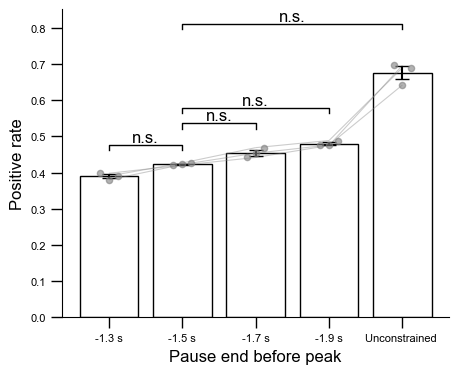

[1.0, 1.0, 1.0, 1.0]


In [131]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ===== サンプルデータ（各条件で同じ順序＝対応あり） =====
# ex_1, ..., ex_5 をあなたのデータに置き換えてください（list/ndarray どちらでもOK）
data1 = po_1
data2 = po_2
data3 = po_3   # 基準（3つ目; control_idx=2 が指す）
data4 = po_4
data5 = po_5

datasets = [np.asarray(d, dtype=float) for d in [data1, data2, data3, data4, data5]]

# ラベル（図のx軸）
labels = ["-1.3 s", "-1.5 s", "-1.7 s", "-1.9 s", "Unconstrained "]

# ====== ナイーブな前処理：長さ不一致・NaNへの頑健化 ======
# すべての条件の最大サンプル数 n を求め、(条件, サンプル) 形にNaN埋め
n = max(len(d) for d in datasets)
Y = np.full((len(datasets), n), np.nan, dtype=float)
for i, d in enumerate(datasets):
    Y[i, :len(d)] = d

# ====== 記述統計（Mean ± SEM；NaNは無視） ======
means = [np.nanmean(Y[i]) for i in range(Y.shape[0])]
sems  = [np.nanstd(Y[i], ddof=1) / np.sqrt(np.sum(np.isfinite(Y[i])))
         for i in range(Y.shape[0])]

# ====== 対応ありの検定：Wilcoxon 符号付順位（両側）で「3つ目 vs 他」 ======
control_idx = 1  # 0始まりで 2 = 3つ目（data3）を基準
pairs = [i for i in range(Y.shape[0]) if i != control_idx]

def paired_clean(a, b):
    """対応ペアをそろえ、両方が有限なペアのみ残す"""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask], b[mask]

p_raw = []
for i in pairs:
    a, b = paired_clean(Y[i], Y[control_idx])
    # ゼロ差分を保守的に扱う 'pratt'、連続性補正あり、p値は mode='auto'（小標本で厳密計算）
    stat, p = stats.wilcoxon(a, b, alternative='two-sided',
                             zero_method='pratt', correction=True, mode='auto')
    p_raw.append(p)

# ====== Holm 補正（FWER制御） ======
reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')
p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}

def p_to_symbol(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ====== プロット ======
x = np.arange(Y.shape[0])
fig, ax = plt.subplots(figsize=(5, 4))

# 棒（Mean ± SEM）
ax.bar(x, means, yerr=sems, capsize=5,
       color="white", edgecolor="black", ecolor="black", linewidth=1)

# 各データ点（薄い丸、少しジッター）
for i in range(Y.shape[0]):
    yi = Y[i]
    ok = np.isfinite(yi)
    d = yi[ok]
    jitter = np.linspace(-0.12, 0.12, d.size) if d.size > 0 else np.array([])
    ax.scatter(np.full(jitter.shape, x[i], dtype=float) + jitter, d,
               s=20, facecolors="gray", edgecolors="gray", alpha=0.6, zorder=2)

# 対応サンプルを線で結ぶ（高速：LineCollection）
segs = []
for j in range(Y.shape[1]):                 # 各サンプル（被験体・試行）について
    xs, ys = [], []
    for i in range(Y.shape[0]):             # すべての条件の点を集める
        y = Y[i, j]
        if np.isfinite(y):
            xs.append(i)
            ys.append(y)
    if len(xs) >= 2:                        # 2点以上あれば線分列を作成
        segs.extend([[(xs[k], ys[k]), (xs[k+1], ys[k+1])]
                     for k in range(len(xs)-1)])

if segs:
    lc = LineCollection(segs, linewidths=0.8, alpha=0.4, colors="gray", zorder=1)
    ax.add_collection(lc)

# 有意差ライン（基準 vs 他）。重ならないように段を上げる
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
base_offset = 0.05 * y_range
step = 0.03 * y_range
line_h = 0.02 * y_range

ps = []
for k, i in enumerate(pairs):
    p = p_holm[i]
    ps.append(p)
    sym = p_to_symbol(p)
    x1, x2 = i, control_idx
    y = max(means[i] + sems[i], means[control_idx] + sems[control_idx]) + base_offset + k*step
    ax.plot([x1, x1, x2, x2], [y, y + line_h, y + line_h, y],
            color="black", linewidth=1)
    ax.text((x1 + x2) / 2, y + line_h, sym, ha="center", va="bottom")

# 体裁
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Positive rate")
ax.set_xlabel("Pause end before peak")
ax.spines[['top','right']].set_visible(False)
#plt.tight_layout()
plt.show()
print(ps)

# ====== 参考：対応のある t検定に切り替える場合 ======
# （正規性が概ね成り立つとみなせる場合に限り、上のwilcoxonループを次で置換）
# p_raw = []
# for i in pairs:
#     a, b = paired_clean(Y[i], Y[control_idx])
#     stat, p = stats.ttest_rel(a, b, alternative='two-sided', nan_policy='omit')
#     p_raw.append(p)
# reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')
# p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}


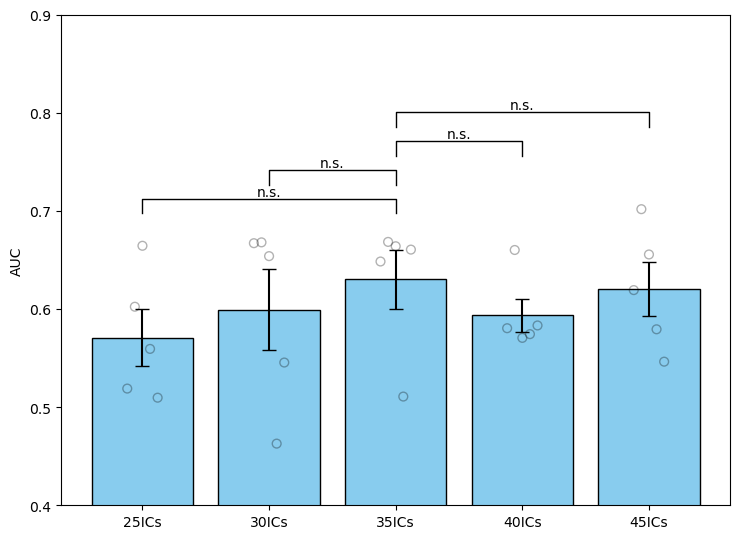

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ------- サンプルデータ（各n=5。ここを書き換えて使う） -------
data1 = auc_1
data2 = auc_2
data3 = auc_3  # 基準（3つ目）
data4 = auc_4
data5 = auc_5

datasets = [data1, data2, data3, data4, data5]
labels   = ["25ICs", "30ICs", "35ICs", "40ICs", "45ICs"]

# ------- 統計量（Mean ± SEM） -------
means = [np.mean(d) for d in datasets]
sems  = [np.std(d, ddof=1) / np.sqrt(len(d)) for d in datasets]

# ------- Wilcoxon rank-sum (Mann–Whitney U)：3つ目 vs 他4群 -------
control_idx = 2
pairs = [i for i in range(len(datasets)) if i != control_idx]  # [0,1,3,4]
p_raw = []
for i in pairs:
    # 独立2群・両側。小標本は exact、ties 等では近似を SciPy に自動選択させる
    stat, p = stats.mannwhitneyu(datasets[i], datasets[control_idx],
                                 alternative='two-sided', method='auto')
    p_raw.append(p)

# ------- Holm 補正 -------
reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')
p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}

def p_to_symbol(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ------- プロット -------
x = np.arange(len(datasets))
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# 棒（Mean ± SEM）
ax.bar(x, means, yerr=sems, capsize=5,
       color="#88ccee", edgecolor="black", ecolor="black", linewidth=1)

# 各データ点（薄い丸、少しジッター）
for i, d in enumerate(datasets):
    jitter = np.linspace(-0.12, 0.12, len(d))
    ax.scatter(np.full_like(d, x[i], dtype=float) + jitter, d,
               s=40, facecolors="none", edgecolors="black", alpha=0.3)

# 有意差ライン（3つ目 vs 他）。重ならないように段を上げる
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
base_offset = 0.05 * y_range    # 棒の上からの余白
step = 0.04 * y_range           # ラインを積み上げる間隔
line_h = 0.02 * y_range

# 段を割り当て（左からの距離で重ならないよう工夫してもOK。ここは単純に順に上げる）
for k, i in enumerate(pairs):
    p = p_holm[i]
    sym = p_to_symbol(p)
    x1, x2 = i, control_idx
    # 比較2本の棒の高い方の上に段差を加える
    y = max(means[i] + sems[i], means[control_idx] + sems[control_idx]) + base_offset + k*step

    # コの字ライン
    ax.plot([x1, x1, x2, x2], [y, y + line_h, y + line_h, y],
            color="black", linewidth=1)

    # 中央に星・n.s.
    ax.text((x1 + x2) / 2, y + line_h, sym, ha="center", va="bottom")

# 体裁
ax.set_ylim(0.4, 0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("AUC")
#ax.set_title("Mean ± SEM (Wilcoxon rank-sum vs 3rd, Holm-corrected)")
plt.tight_layout()
plt.show()


In [2]:
dl_1 = "Vis_angle_multi_66"
dl_2 = "Vis_angle_multi_67"
#dl_3 = "Vis_angle_multi_23"
#dl_4 = "Vis_angle_multi_24"
#dl_5 = "Vis_angle_multi_25"

loss_1 = np.load(f"{dl_folder}/model_{dl_1}/{date}_{dl_1}_valid_loss_best.npy")
loss_2 = np.load(f"{dl_folder}/model_{dl_2}/{date}_{dl_2}_valid_loss_best.npy")
#loss_3 = np.load(f"{dl_folder}/model_{dl_3}/{date}_{dl_3}_valid_loss_best.npy")
#loss_4 = np.load(f"{dl_folder}/model_{dl_4}/{date}_{dl_4}_valid_loss_best.npy")
#loss_5 = np.load(f"{dl_folder}/model_{dl_5}/{date}_{dl_5}_valid_loss_best.npy")



auc_1 = np.load(f"{dl_folder}/model_{dl_1}/{date}_{dl_1}_valid_auc_best.npy")
auc_2 = np.load(f"{dl_folder}/model_{dl_2}/{date}_{dl_2}_valid_auc_best.npy")
#auc_3 = np.load(f"{dl_folder}/model_{dl_3}/{date}_{dl_3}_valid_auc_best.npy")
#auc_4 = np.load(f"{dl_folder}/model_{dl_4}/{date}_{dl_4}_valid_auc_best.npy")
#auc_5 = np.load(f"{dl_folder}/model_{dl_5}/{date}_{dl_5}_valid_auc_best.npy")

acc_1 = np.load(f"{dl_folder}/model_{dl_1}/{date}_{dl_1}_valid_accuracy_best.npy")
acc_2 = np.load(f"{dl_folder}/model_{dl_2}/{date}_{dl_2}_valid_accuracy_best.npy")

t=-1.515, p=0.2044


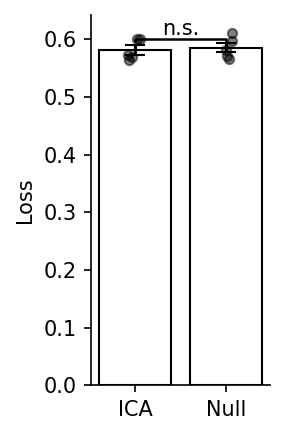

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def significance_stars(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:   # 0.01 >= p > 0.05 は起こらないのでこの順でOK
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

def barplot_with_stats(a, b, paired=False, ylabel="Value", group_labels=("Group1", "Group2")):
    a = np.asarray(a); b = np.asarray(b)
    # 統計検定
    #if paired:
    t_stat, p_val = stats.ttest_rel(a, b)          # 対応あり t 検定。a,bは同じ長さ。:contentReference[oaicite:1]{index=1}
    #else:
    #    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)  # Welch の t 検定（等分散を仮定しない）。:contentReference[oaicite:2]{index=2}

    # 平均と標準誤差（SEM）
    means = [np.mean(a), np.mean(b)]
    sems  = [stats.sem(a, ddof=1), stats.sem(b, ddof=1)]       # 標準誤差。:contentReference[oaicite:3]{index=3}

    # プロット
    fig, ax = plt.subplots(figsize=(2,3), dpi=150)
    x = np.arange(2)

    # 棒＋エラーバー
    bars = ax.bar(x, means, yerr=sems, capsize=5, color='white', edgecolor='black', alpha=1)
    # 各要素の値（薄い丸）を重ねる（軽いジッター＆透過）
    rng = np.random.default_rng(0)
    jitter = (rng.uniform(-0.08, 0.08, size=len(a)), rng.uniform(-0.08, 0.08, size=len(b)))
    ax.scatter(np.full_like(a, x[0]) + jitter[0], a, s=20, color='black', edgecolor='black', alpha=0.5)
    ax.scatter(np.full_like(b, x[1]) + jitter[1], b, s=20, color='black', edgecolor='black', alpha=0.5)

    # 有意差アノテーション（括弧と星）
    star = significance_stars(p_val)
    y_max = max(means[0] + sems[0], means[1] + sems[1])
    h = 0.08 * (np.max([*a, *b]) - np.min([*a, *b]) + 1e-12)  # 括弧の高さ
    y1, y2 = y_max + h, y_max + h*1.6
    ax.plot([x[0], x[0], x[1], x[1]], [y1, y2, y2, y1], lw=1.2, c="black")
    ax.text((x[0]+x[1])/2, y2 + h*0.2, star, ha="center", va="bottom")

    # 軸など
    ax.set_xticks(x); ax.set_xticklabels(list(group_labels))
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    return p_val, t_stat, fig, ax

# 例：n=5 の2群（適当にダミーデータ）
a = loss_1
b = loss_2

p, t, fig, ax = barplot_with_stats(a, b, paired=False, ylabel="Loss", group_labels=("ICA", "Null"))
print(f"t={t:.3f}, p={p:.4f}")
plt.show()


t=2.897, p=0.0443


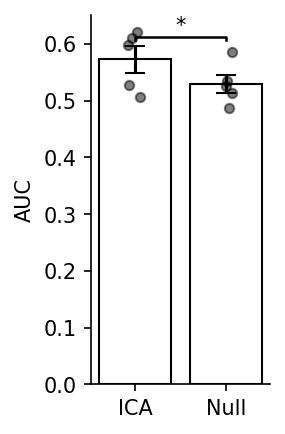

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def significance_stars(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:   # 0.01 >= p > 0.05 は起こらないのでこの順でOK
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

def barplot_with_stats(a, b, paired=False, ylabel="Value", group_labels=("Group1", "Group2")):
    a = np.asarray(a); b = np.asarray(b)
    # 統計検定
    #if paired:
    #    t_stat, p_val = stats.ttest_rel(a, b)          # 対応あり t 検定。a,bは同じ長さ。:contentReference[oaicite:1]{index=1}
    t_stat, p_val = stats.ttest_rel(a, b)  
    #else:
    #    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)  # Welch の t 検定（等分散を仮定しない）。:contentReference[oaicite:2]{index=2}

    # 平均と標準誤差（SEM）
    means = [np.mean(a), np.mean(b)]
    sems  = [stats.sem(a, ddof=1), stats.sem(b, ddof=1)]       # 標準誤差。:contentReference[oaicite:3]{index=3}

    # プロット
    fig, ax = plt.subplots(figsize=(2,3), dpi=150)
    x = np.arange(2)

    # 棒＋エラーバー
    bars = ax.bar(x, means, yerr=sems, capsize=5, color='white', edgecolor='black', alpha=1)
    # 各要素の値（薄い丸）を重ねる（軽いジッター＆透過）
    rng = np.random.default_rng(0)
    jitter = (rng.uniform(-0.08, 0.08, size=len(a)), rng.uniform(-0.08, 0.08, size=len(b)))
    ax.scatter(np.full_like(a, x[0]) + jitter[0], a, s=20, color='black', edgecolor='black', alpha=0.5)
    ax.scatter(np.full_like(b, x[1]) + jitter[1], b, s=20, color='black', edgecolor='black', alpha=0.5)

    # 有意差アノテーション（括弧と星）
    star = significance_stars(p_val)
    y_max = max(means[0] + sems[0], means[1] + sems[1])
    h = 0.08 * (np.max([*a, *b]) - np.min([*a, *b]) + 1e-12)  # 括弧の高さ
    y1, y2 = y_max + h, y_max + h*1.6
    ax.plot([x[0], x[0], x[1], x[1]], [y1, y2, y2, y1], lw=1.2, c="black")
    ax.text((x[0]+x[1])/2, y2 + h*0.2, star, ha="center", va="bottom")

    # 軸など
    ax.set_xticks(x); ax.set_xticklabels(list(group_labels))
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    return p_val, t_stat, fig, ax

# 例：n=5 の2群（適当にダミーデータ）
a = auc_1
b = auc_2

#a = np.delete(auc_1, 3)
#b = np.delete(auc_2, 3)

p, t, fig, ax = barplot_with_stats(a, b, paired=False, ylabel="AUC", group_labels=("ICA", "Null"))
print(f"t={t:.3f}, p={p:.4f}")
plt.show()


t=-1.114, p=0.3276


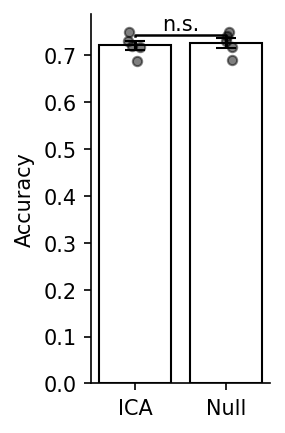

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def significance_stars(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:   # 0.01 >= p > 0.05 は起こらないのでこの順でOK
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

def barplot_with_stats(a, b, paired=False, ylabel="Value", group_labels=("Group1", "Group2")):
    a = np.asarray(a); b = np.asarray(b)
    # 統計検定
    #if paired:
    #    t_stat, p_val = stats.ttest_rel(a, b)          # 対応あり t 検定。a,bは同じ長さ。:contentReference[oaicite:1]{index=1}
    t_stat, p_val = stats.ttest_rel(a, b)  
    #else:
    #    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)  # Welch の t 検定（等分散を仮定しない）。:contentReference[oaicite:2]{index=2}

    # 平均と標準誤差（SEM）
    means = [np.mean(a), np.mean(b)]
    sems  = [stats.sem(a, ddof=1), stats.sem(b, ddof=1)]       # 標準誤差。:contentReference[oaicite:3]{index=3}

    # プロット
    fig, ax = plt.subplots(figsize=(2,3), dpi=150)
    x = np.arange(2)

    # 棒＋エラーバー
    bars = ax.bar(x, means, yerr=sems, capsize=5, color='white', edgecolor='black', alpha=1)
    # 各要素の値（薄い丸）を重ねる（軽いジッター＆透過）
    rng = np.random.default_rng(0)
    jitter = (rng.uniform(-0.08, 0.08, size=len(a)), rng.uniform(-0.08, 0.08, size=len(b)))
    ax.scatter(np.full_like(a, x[0]) + jitter[0], a, s=20, color='black', edgecolor='black', alpha=0.5)
    ax.scatter(np.full_like(b, x[1]) + jitter[1], b, s=20, color='black', edgecolor='black', alpha=0.5)

    # 有意差アノテーション（括弧と星）
    star = significance_stars(p_val)
    y_max = max(means[0] + sems[0], means[1] + sems[1])
    h = 0.08 * (np.max([*a, *b]) - np.min([*a, *b]) + 1e-12)  # 括弧の高さ
    y1, y2 = y_max + h, y_max + h*1.6
    ax.plot([x[0], x[0], x[1], x[1]], [y1, y2, y2, y1], lw=1.2, c="black")
    ax.text((x[0]+x[1])/2, y2 + h*0.2, star, ha="center", va="bottom")

    # 軸など
    ax.set_xticks(x); ax.set_xticklabels(list(group_labels))
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    return p_val, t_stat, fig, ax

# 例：n=5 の2群（適当にダミーデータ）
a = acc_1
b = acc_2

#a = np.delete(auc_1, 3)
#b = np.delete(auc_2, 3)

p, t, fig, ax = barplot_with_stats(a, b, paired=False, ylabel="Accuracy", group_labels=("ICA", "Null"))
print(f"t={t:.3f}, p={p:.4f}")
plt.show()


In [41]:
null_dl = "Vis_angle_multi_61"
ica_dl = "Vis_angle_multi_60"

null_ic = np.load(f"{dl_folder}/model_{null_dl}/{date}_{null_dl}_mean_shap_ic.npy")
null_allen = np.load(f"{dl_folder}/model_{null_dl}/{date}_{null_dl}_mean_shap_allen.npy")

ica_ic = np.load(f"{dl_folder}/model_{ica_dl}/{date}_{ica_dl}_mean_shap_ic.npy")
ica_allen = np.load(f"{dl_folder}/model_{ica_dl}/{date}_{ica_dl}_mean_shap_allen.npy")

print(null_ic.shape, null_allen.shape)
print(ica_ic.shape, ica_allen.shape)

(5, 21, 23) (5, 21, 26)
(5, 21, 23) (5, 21, 26)


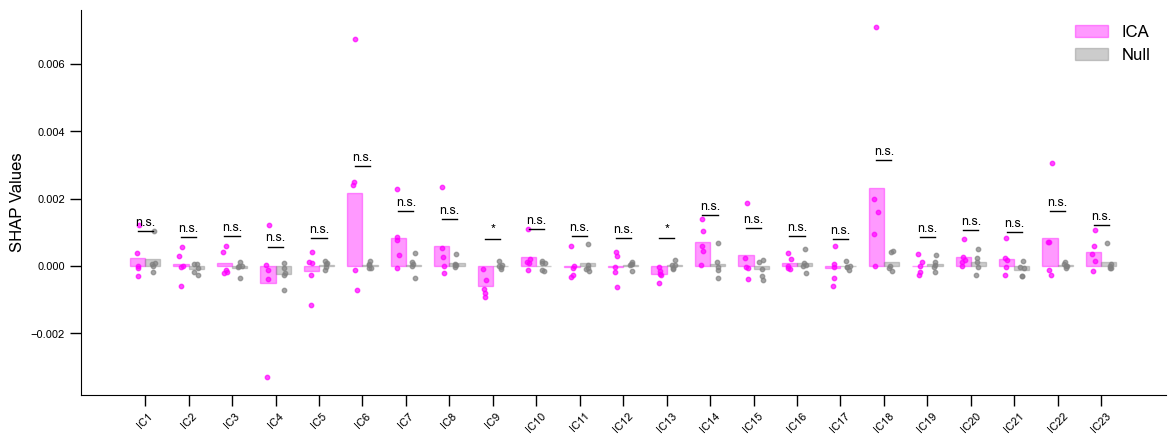

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.003, +0.003

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_ic[:, 10:19], axis=1).transpose()
data2 = np.mean(null_ic[:, 10:19], axis=1).transpose()

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    #t, p = stats.ttest_ind(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(14, 5))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4)
bars2 = ax.bar(x + width/2, means2, width, label='Null', color='gray', edgecolor='gray', alpha=0.4)

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.001 * (y_max)  # バーの高さ
    y = bar_max + 0.001 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.0002 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


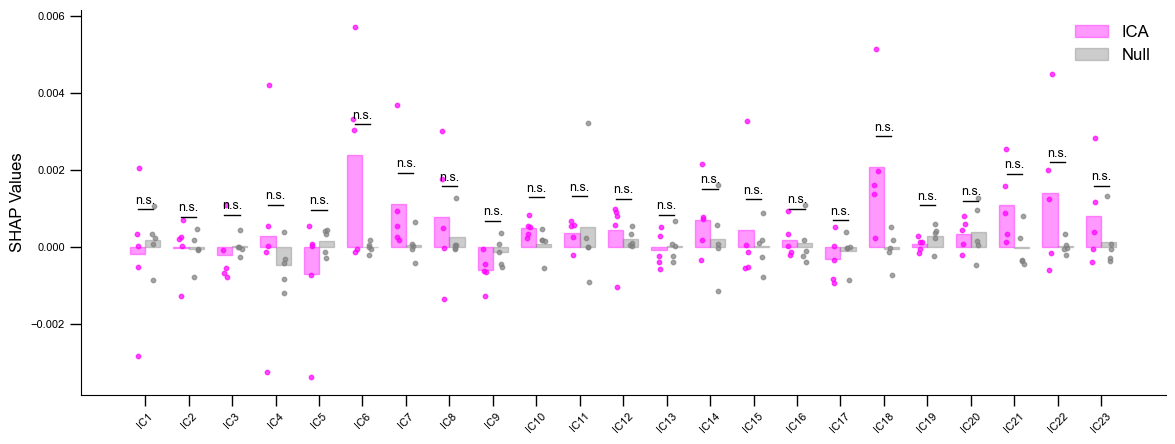

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.003, +0.003

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_ic[:, 14:], axis=1).transpose()
data2 = np.mean(null_ic[:, 14:], axis=1).transpose()

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    #t, p = stats.ttest_ind(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(14, 5))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4)
bars2 = ax.bar(x + width/2, means2, width, label='Null', color='gray', edgecolor='gray', alpha=0.4)

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.001 * (y_max)  # バーの高さ
    y = bar_max + 0.001 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.0002 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


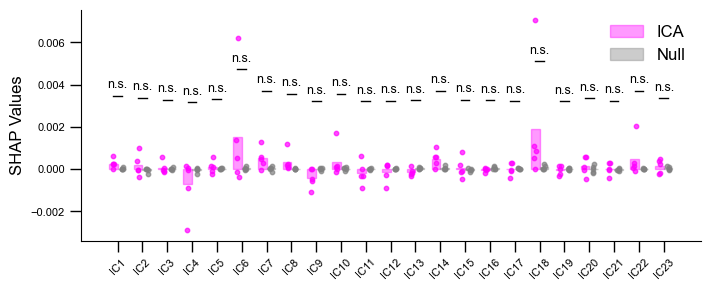

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.003, +0.003

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_ic[:, 10:14], axis=1).transpose()
data2 = np.mean(null_ic[:, 10:14], axis=1).transpose()

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(8, 3))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4)
bars2 = ax.bar(x + width/2, means2, width, label='Null', color='gray', edgecolor='gray', alpha=0.4)

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.004 * (y_max)  # バーの高さ
    y = bar_max + 0.004 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.0006 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


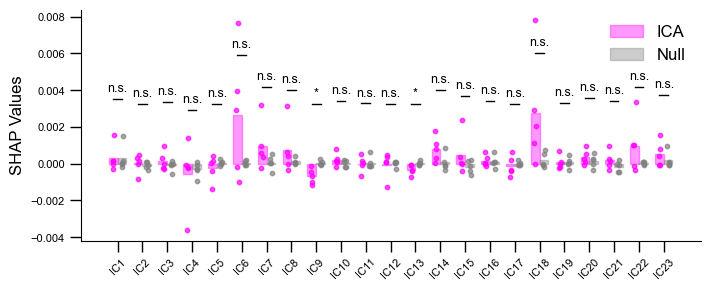

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.003, +0.003

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_ic[:, 14:18], axis=1).transpose()
data2 = np.mean(null_ic[:, 14:18], axis=1).transpose()

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(8, 3))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4)
bars2 = ax.bar(x + width/2, means2, width, label='Null', color='gray', edgecolor='gray', alpha=0.4)

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.004 * (y_max)  # バーの高さ
    y = bar_max + 0.004 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.0006 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


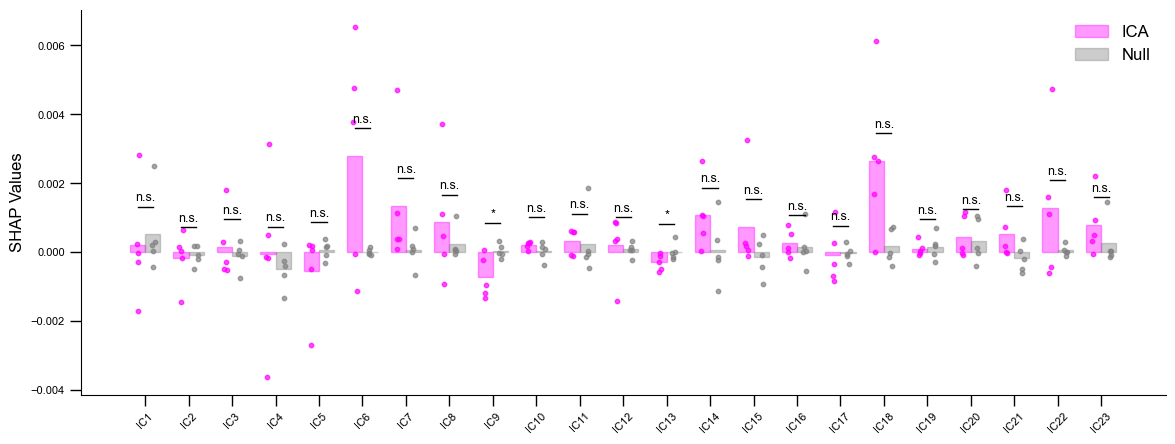

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.003, +0.003

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_ic[:, 16:19], axis=1).transpose()
data2 = np.mean(null_ic[:, 16:19], axis=1).transpose()

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(14, 5))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4)
bars2 = ax.bar(x + width/2, means2, width, label='Null', color='gray', edgecolor='gray', alpha=0.4)

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.001 * (y_max)  # バーの高さ
    y = bar_max + 0.001 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.0002 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


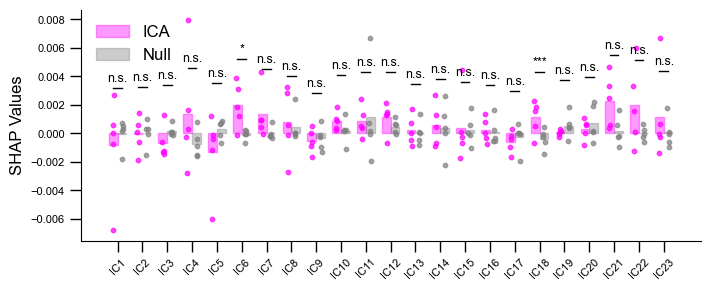

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.003, +0.003

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_ic[:, 18:21], axis=1).transpose()
data2 = np.mean(null_ic[:, 18:21], axis=1).transpose()

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(8, 3))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4)
bars2 = ax.bar(x + width/2, means2, width, label='Null', color='gray', edgecolor='gray', alpha=0.4)

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.004 * (y_max)  # バーの高さ
    y = bar_max + 0.004 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.0006 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


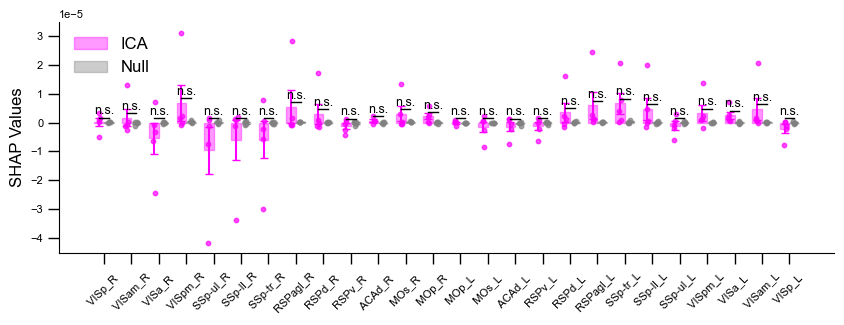

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.001, +0.001

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_allen[:, :14], axis=1).transpose()
data2 = np.mean(null_allen[:, :14], axis=1).transpose()

n1 = data1.shape[1]
n2 = data2.shape[1]

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(10, 3))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# SEM（標準誤差）
sems1 = data1.std(axis=1, ddof=1) / np.sqrt(n1)
sems2 = data2.std(axis=1, ddof=1) / np.sqrt(n2)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, yerr=sems1, capsize=3, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4, error_kw=dict(ecolor='magenta'))
bars2 = ax.bar(x + width/2, means2, width, yerr=sems2, capsize=3, label='Null', color='gray', edgecolor='gray', alpha=0.4, error_kw=dict(ecolor='gray'))

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.000002 * (y_max)  # バーの高さ
    y = bar_max + 0.000002 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.0000002 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
#ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_xticklabels(roi_names, rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


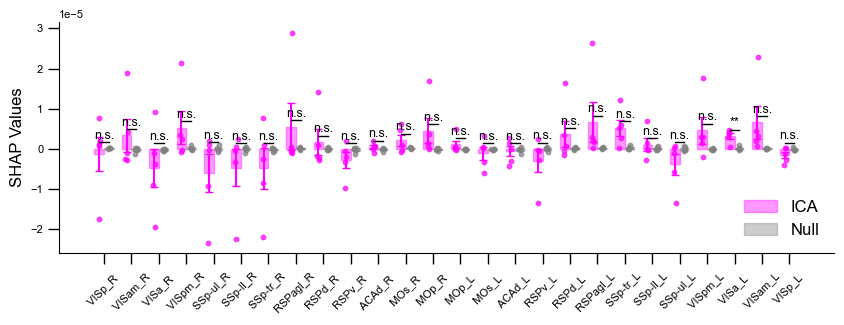

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.001, +0.001

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_allen[:, 8:11], axis=1).transpose()
data2 = np.mean(null_allen[:, 8:11], axis=1).transpose()

n1 = data1.shape[1]
n2 = data2.shape[1]

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(10, 3))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# SEM（標準誤差）
sems1 = data1.std(axis=1, ddof=1) / np.sqrt(n1)
sems2 = data2.std(axis=1, ddof=1) / np.sqrt(n2)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, yerr=sems1, capsize=3, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4, error_kw=dict(ecolor='magenta'))
bars2 = ax.bar(x + width/2, means2, width, yerr=sems2, capsize=3, label='Null', color='gray', edgecolor='gray', alpha=0.4, error_kw=dict(ecolor='gray'))

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.000002 * (y_max)  # バーの高さ
    y = bar_max + 0.000002 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.0000002 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
#ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_xticklabels(roi_names, rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


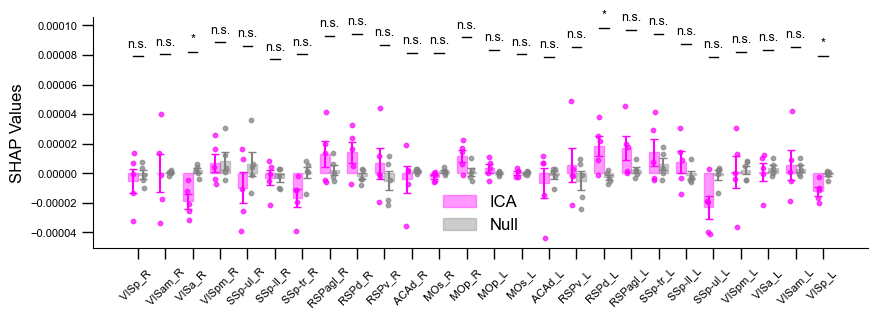

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.001, +0.001

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_allen[:, 16:19], axis=1).transpose()
data2 = np.mean(null_allen[:, 16:19], axis=1).transpose()

n1 = data1.shape[1]
n2 = data2.shape[1]

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(10, 3))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# SEM（標準誤差）
sems1 = data1.std(axis=1, ddof=1) / np.sqrt(n1)
sems2 = data2.std(axis=1, ddof=1) / np.sqrt(n2)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, yerr=sems1, capsize=3, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4, error_kw=dict(ecolor='magenta'))
bars2 = ax.bar(x + width/2, means2, width, yerr=sems2, capsize=3, label='Null', color='gray', edgecolor='gray', alpha=0.4, error_kw=dict(ecolor='gray'))

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.0001 * (y_max)  # バーの高さ
    y = bar_max + 0.0001 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.00001 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
#ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_xticklabels(roi_names, rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


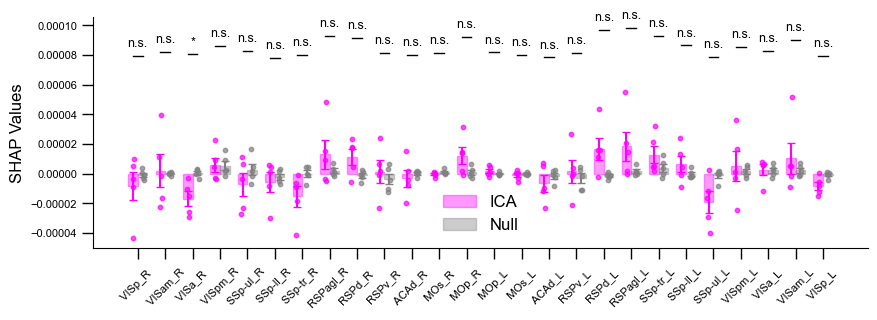

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.001, +0.001

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_allen[:, 14:18], axis=1).transpose()
data2 = np.mean(null_allen[:, 14:18], axis=1).transpose()

n1 = data1.shape[1]
n2 = data2.shape[1]

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(10, 3))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# SEM（標準誤差）
sems1 = data1.std(axis=1, ddof=1) / np.sqrt(n1)
sems2 = data2.std(axis=1, ddof=1) / np.sqrt(n2)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, yerr=sems1, capsize=3, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4, error_kw=dict(ecolor='magenta'))
bars2 = ax.bar(x + width/2, means2, width, yerr=sems2, capsize=3, label='Null', color='gray', edgecolor='gray', alpha=0.4, error_kw=dict(ecolor='gray'))

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.0001 * (y_max)  # バーの高さ
    y = bar_max + 0.0001 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.00001 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
#ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_xticklabels(roi_names, rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


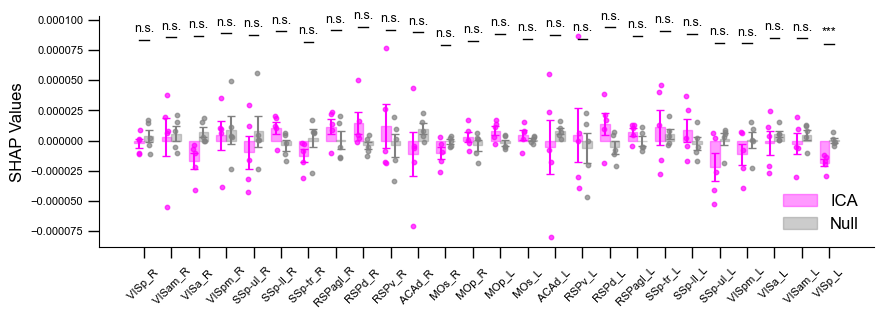

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#vmin, vmax=-3e-5, +3e-5
vmin, vmax=-0.001, +0.001

# 例：ダミーデータ（25組, 各n=5）
# 実データではここを書き換えてください
np.random.seed(0)
#data1 = np.random.normal(loc=1.0, scale=0.3, size=(25, 5))
#data2 = np.random.normal(loc=1.2, scale=0.3, size=(25, 5))
data1 =  np.mean(ica_allen[:, 18:], axis=1).transpose()
data2 = np.mean(null_allen[:, 18:], axis=1).transpose()

n1 = data1.shape[1]
n2 = data2.shape[1]

#assert data1.shape == data2.shape == (25, 5)

def get_sig_label(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ペアごとに対応のあるt検定
p_values = []
for i in range(data1.shape[0]):
    t, p = stats.ttest_rel(data1[i], data2[i])
    p_values.append(p)

# 描画
fig, ax = plt.subplots(figsize=(10, 3))

n_pairs = data1.shape[0]
x = np.arange(n_pairs)
width = 0.35  # 2本の棒の幅

means1 = data1.mean(axis=1)
means2 = data2.mean(axis=1)

# SEM（標準誤差）
sems1 = data1.std(axis=1, ddof=1) / np.sqrt(n1)
sems2 = data2.std(axis=1, ddof=1) / np.sqrt(n2)

# 棒グラフ（平均）
bars1 = ax.bar(x - width/2, means1, width, yerr=sems1, capsize=3, label='ICA', color='magenta', edgecolor='magenta', alpha=0.4, error_kw=dict(ecolor='magenta'))
bars2 = ax.bar(x + width/2, means2, width, yerr=sems2, capsize=3, label='Null', color='gray', edgecolor='gray', alpha=0.4, error_kw=dict(ecolor='gray'))

# 各データ点を薄い丸でプロット（対応ありなのでx位置を揃えて少しだけずらす）
for i in range(n_pairs):
    # jitterを少し
    jitter1 = (np.random.rand(5) - 0.5) * 0.10
    jitter2 = (np.random.rand(5) - 0.5) * 0.10
    ax.scatter(
        np.full(5, x[i] - width/2) + jitter1,
        data1[i],
        s=10,
        facecolors='magenta',
        edgecolors='magenta',
        alpha=0.7
    )
    ax.scatter(
        np.full(5, x[i] + width/2) + jitter2,
        data2[i],
        s=10,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.7
    )

# 有意差バー & ラベル
y_max = max(ax.get_ylim()[1], (np.maximum(means1, means2) + 0.4).max())
#ax.set_ylim(ax.get_ylim()[0], y_max)
#ax.set_ylim(vmin, vmax)

for i in range(n_pairs):
    p = p_values[i]
    label = get_sig_label(p)

    # nsのときも表示したい指示なのでそのまま描く
    # （邪魔なら if label != "n.s.": に変えてください）
    x1 = x[i] - width/2
    x2 = x[i] + width/2

    # このペアの棒の一番高い方より少し上に線を描く
    bar_max = max(bars1[i].get_height(), bars2[i].get_height())
    h = 0.0001 * (y_max)  # バーの高さ
    y = bar_max + 0.0001 * y_max

    # 線
    ax.plot(
#            [x1, x1, x2, x2],
#            [y,  y + h, y + h, y],
            [x1, x2],
            [y + h, y + h],
            lw=1,
            c='black')

    # ラベル
    ax.text((x1 + x2)/2,
            y + h + 0.00001 * y_max,
            label,
            ha='center',
            va='bottom',
            fontsize=9)

ax.set_xticks(x)
#ax.set_xticklabels([f'IC{i+1}' for i in range(n_pairs)], rotation=45)
ax.set_xticklabels(roi_names, rotation=45)
ax.set_ylabel('SHAP Values')
ax.legend(frameon=False)
#plt.tight_layout()
plt.show()


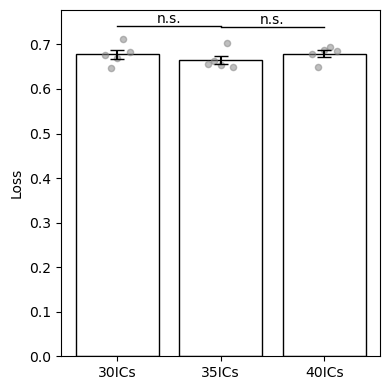

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ------- サンプルデータ（ここを書き換えて使ってください） -------
# 各データセットは長さ5（独立サンプルを想定）
data1 = loss_1
data2 = loss_2  # 基準（2つ目）
data3 = loss_3
#data4 = loss_4

datasets = [data1, data2, data3]
labels   = ["30ICs", "35ICs", "40ICs"]

# ------- 平均 & 標準誤差 (Mean ± SEM) -------
means = [np.mean(d) for d in datasets]
sems  = [np.std(d, ddof=1) / np.sqrt(len(d)) for d in datasets]

# ------- Wilcoxon rank-sum test (Mann-Whitney U) vs 2つ目 + Holm補正 -------
# 比較するのは:
#   Cond1 vs Cond2
#   Cond3 vs Cond2
# 独立2標本・両側検定とする
pairs = [0, 2]          # 2番目(インデックス1)と比べる相手
p_raw = []

for i in pairs:
    u_stat, p = stats.mannwhitneyu(datasets[i], data3, alternative='two-sided')
    p_raw.append(p)

# Holm-Bonferroni 法で多重比較補正
# multipletests は SciPy ではなく statsmodels.stats.multitest を使用
reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')

# 結果をインデックスに対応付け
p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}

def p_to_symbol(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ------- プロット -------
x = np.arange(3)
fig, ax = plt.subplots(figsize=(4, 4))

# 棒グラフ（Mean ± SEM）
bars = ax.bar(
    x, means,
    yerr=sems,
    capsize=5,
    color="white",
    edgecolor="black",
    ecolor="black",
    linewidth=1
)

# 各データ点を薄い丸で描画（少し横に散らす）
for i, d in enumerate(datasets):
    jitter = np.linspace(-0.12, 0.12, len(d))
    ax.scatter(
        np.full_like(d, x[i], dtype=float) + jitter,
        d,
        s=20,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.5
    )

# ------- 有意差ライン & 記号（Holm補正後 p値を使用） -------
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
line_offset = 0.05 * y_range
line_height = 0.02 * y_range

for i in pairs:
    p = p_holm[i]
    sym = p_to_symbol(p)

    x1, x2 = i, 1  # 比較: i vs 2番目(インデックス1)
    y = max(means[i] + sems[i], means[1] + sems[1]) + line_offset

    # コの字ライン
    ax.plot(
        [x1, x2],
        [y + line_height, y + line_height],
        color="black",
        linewidth=1
    )

    # 中央に "n.s." や "*"
    ax.text(
        (x1 + x2) / 2,
        y + line_height,
        sym,
        ha="center",
        va="bottom"
    )

# 軸ラベルなど
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Loss")
#ax.set_title("Mean ± SEM (Wilcoxon rank-sum vs 2nd, Holm-corrected)")

plt.tight_layout()
plt.show()


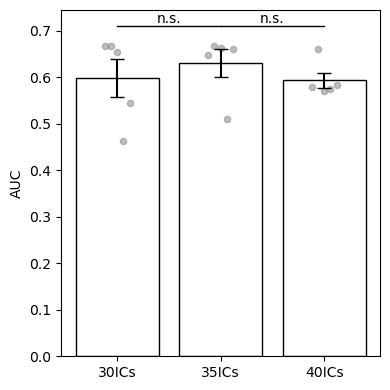

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ------- サンプルデータ（ここを書き換えて使ってください） -------
# 各データセットは長さ5（独立サンプルを想定）
data1 = auc_1
data2 = auc_2  # 基準（2つ目）
data3 = auc_3
#data4 = auc_4

datasets = [data1, data2, data3]
labels   = ["30ICs", "35ICs", "40ICs"]

# ------- 平均 & 標準誤差 (Mean ± SEM) -------
means = [np.mean(d) for d in datasets]
sems  = [np.std(d, ddof=1) / np.sqrt(len(d)) for d in datasets]

# ------- Wilcoxon rank-sum test (Mann-Whitney U) vs 2つ目 + Holm補正 -------
# 比較するのは:
#   Cond1 vs Cond2
#   Cond3 vs Cond2
# 独立2標本・両側検定とする
pairs = [0, 2]          # 2番目(インデックス1)と比べる相手
p_raw = []

for i in pairs:
    u_stat, p = stats.mannwhitneyu(datasets[i], data3, alternative='two-sided')
    p_raw.append(p)

# Holm-Bonferroni 法で多重比較補正
# multipletests は SciPy ではなく statsmodels.stats.multitest を使用
reject, p_adj, _, _ = multipletests(p_raw, alpha=0.05, method='holm')

# 結果をインデックスに対応付け
p_holm = {pairs[i]: p_adj[i] for i in range(len(pairs))}

def p_to_symbol(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.005:
        return "**"
    else:
        return "***"

# ------- プロット -------
x = np.arange(3)
fig, ax = plt.subplots(figsize=(4, 4))

# 棒グラフ（Mean ± SEM）
bars = ax.bar(
    x, means,
    yerr=sems,
    capsize=5,
    color="white",
    edgecolor="black",
    ecolor="black",
    linewidth=1
)

# 各データ点を薄い丸で描画（少し横に散らす）
for i, d in enumerate(datasets):
    jitter = np.linspace(-0.12, 0.12, len(d))
    ax.scatter(
        np.full_like(d, x[i], dtype=float) + jitter,
        d,
        s=20,
        facecolors='gray',
        edgecolors='gray',
        alpha=0.5
    )

# ------- 有意差ライン & 記号（Holm補正後 p値を使用） -------
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
line_offset = 0.05 * y_range
line_height = 0.02 * y_range

for i in pairs:
    p = p_holm[i]
    sym = p_to_symbol(p)

    x1, x2 = i, 1  # 比較: i vs 2番目(インデックス1)
    y = max(means[i] + sems[i], means[1] + sems[1]) + line_offset

    # コの字ライン
    ax.plot(
        [x1, x2],
        [y + line_height, y + line_height],
        color="black",
        linewidth=1
    )

    # 中央に "n.s." や "*"
    ax.text(
        (x1 + x2) / 2,
        y + line_height,
        sym,
        ha="center",
        va="bottom"
    )

# 軸ラベルなど
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("AUC")
#ax.set_title("Mean ± SEM (Wilcoxon rank-sum vs 2nd, Holm-corrected)")

plt.tight_layout()
plt.show()


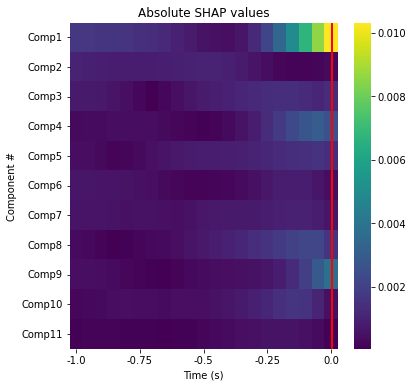

In [11]:
show_shap_abs_mean(mean_shaps)

In [48]:
roi_traces.shape

(26, 3, 21)

In [80]:
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt

def make_bar_shap(shap_val, start_frame, start_time, end_frame, end_time):

    #predata = np.sum(np.abs(shap_val[:, start_frame:end_frame]), axis= 1).transpose()
    predata = np.sum(shap_val[:, start_frame:end_frame], axis= 1).transpose()
    data = predata.tolist()

    group_names = [str(i) for i in range(1, predata.shape[0]+1)]
    #group_names = areanames
    # 平均値と標準誤差の計算
    means = [np.mean(group) for group in data]
    sems = [stats.sem(group) for group in data]

    # 平均値が最も高いグループを特定
    max_mean_index = np.argmax(means)

    # Wilcoxon rank-sum testの実行
    p_values = []
    for i, group in enumerate(data):
        if i != max_mean_index:
            _, p = stats.ranksums(data[max_mean_index], group)
            p_values.append(p)
        else:
            p_values.append(1)  # 最大平均値のグループ自身との比較のため

    # Holm補正の適用
    _, p_corrected, _, _ = multipletests(p_values, method='holm')

    # グラフの作成
    plt.figure(figsize=(15, 6))
    bars = plt.bar(group_names, means, yerr=sems, capsize=5, color='gray')
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.xlabel("IC #", fontsize=12, labelpad=10)  # ラベルのパディングを増やす
    plt.ylabel("Cumulative absolute SHAP values", fontsize=15)

    offset1 = 0.03 * max(abs(np.array(means)))
    offset2 = 0.12 * max(abs(np.array(means)))

    # 有意差のあるグループに*を付ける
    for i, (p, bar) in enumerate(zip(p_corrected, bars)):
        if p>=0.05 and i != max_mean_index:
            mean = means[i]
            err = sems[i]
            if mean >= 0:
                height = mean + err + offset1
                va = 'bottom'
            else:
                height = mean - err - offset2
                va = 'top'
            plt.text(bar.get_x() + bar.get_width()/2, height, 'n.s.',
                    ha='center', va='bottom', fontsize=12)
        if p < 0.05 and p>=0.01 and i != max_mean_index:
            mean = means[i]
            err = sems[i]
            if mean >= 0:
                height = mean + err + offset1
                va = 'bottom'
            else:
                height = mean - err - offset2
                va = 'top'
            plt.text(bar.get_x() + bar.get_width()/2, height, '*',
                    ha='center', va='bottom', fontsize=12)
        if p < 0.01 and p>=0.005 and i != max_mean_index:
            mean = means[i]
            err = sems[i]
            if mean >= 0:
                height = mean + err + offset1
                va = 'bottom'
            else:
                height = mean - err - offset2
                va = 'top'
            plt.text(bar.get_x() + bar.get_width()/2, height, '**',
                    ha='center', va='bottom', fontsize=12)
        if p < 0.005 and i != max_mean_index:
            mean = means[i]
            err = sems[i]
            if mean >= 0:
                height = mean + err + offset1
                va = 'bottom'
            else:
                height = mean - err - offset2
                va = 'top'
            plt.text(bar.get_x() + bar.get_width()/2, height, '***',
                    ha='center', va='bottom', fontsize=12)
            

    # 最大平均値のグループを強調
    bars[max_mean_index].set_color('magenta')
    max_mean = means[max_mean_index]
    max_sem = sems[max_mean_index]
    if max_mean >= 0:
        max_label_height = max_mean + max_sem + offset1
        max_label_va = 'bottom'
    else:
        max_label_height = max_mean - max_sem - offset2
        max_label_va = 'top'
    plt.text(max_mean_index, max_label_height, 'Max',
            ha='center', va=max_label_va, fontsize=12)

    # y軸の範囲を調整して、マークが見切れないようにする
    #y_min = min(means) - max(sems) * 1
    y_min = -0.05
    y_max = max(means) + max(sems) * 2
    #plt.ylim(y_min, y_max)

    plt.xticks(range(predata.shape[0]), roi_names, rotation=45)
    plt.tick_params(axis='x', which='major', labelsize=15, pad=5)
    plt.tick_params(axis='y', which='major', labelsize=15, pad=5)

    #plt.title("-0.5 ~ -0.3 sec", fontsize=20, fontweight='bold')
    plt.title(f"{start_time} ~ {end_time} sec", fontsize=18, fontweight='bold')

    # x軸に目盛りを追加
    plt.tight_layout()
    plt.show()

    # 結果の表示（オプション）
    results = pd.DataFrame({
        'Group': roi_names,
        'Mean': means,
        'SEM': sems,
        'P-value': p_values,
        'Corrected P-value': p_corrected,
        'Significant': p_corrected < 0.05
    })

    print("最も平均値が高いグループ: Group {}".format(roi_names[max_mean_index]))
    print(results)

    # 'Significant'がFalseなgroupをリストにする
    non_significant_groups = results[results['Significant'] == False]['Group'].tolist()

    print("最重要ROIs")
    print(non_significant_groups)

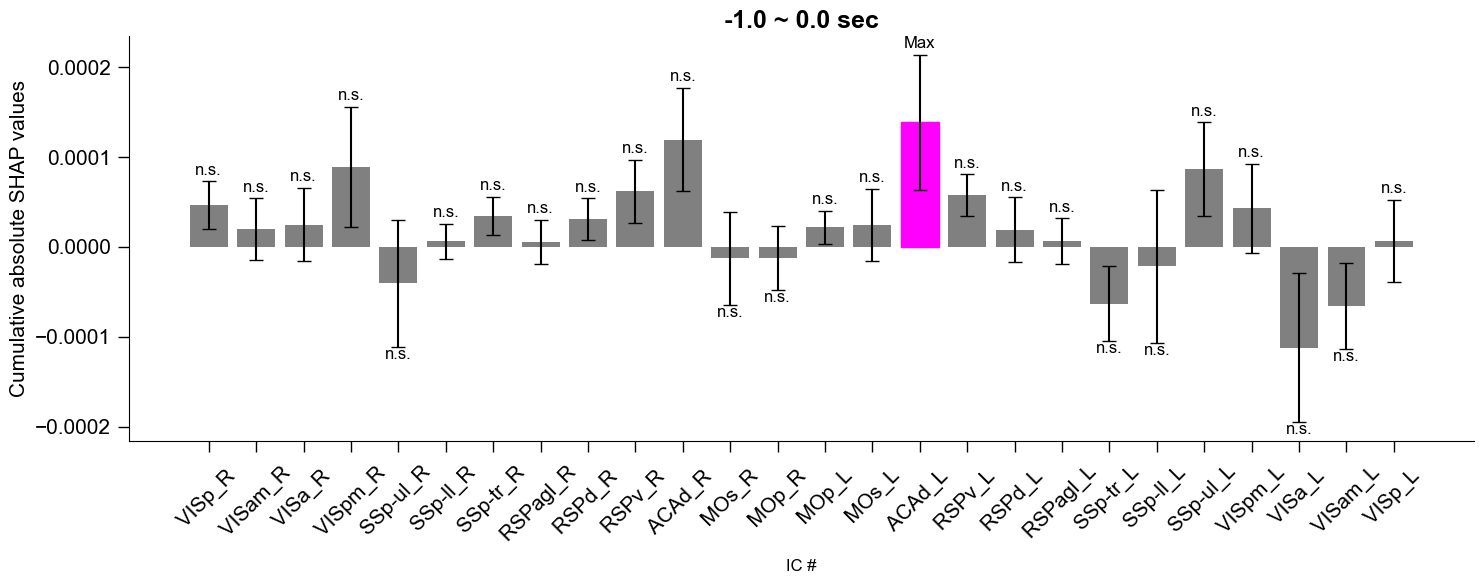

最も平均値が高いグループ: Group  ACAd_L  
        Group      Mean       SEM   P-value  Corrected P-value  Significant
0    VISp_R    0.000047  0.000026  0.464702                1.0        False
1    VISam_R   0.000020  0.000034  0.174525                1.0        False
2    VISa_R    0.000025  0.000041  0.347208                1.0        False
3    VISpm_R   0.000089  0.000067  0.754023                1.0        False
4   SSp-ul_R  -0.000040  0.000071  0.174525                1.0        False
5   SSp-ll_R   0.000007  0.000020  0.117185                1.0        False
6   SSp-tr_R   0.000035  0.000021  0.347208                1.0        False
7   RSPagl_R   0.000005  0.000025  0.250592                1.0        False
8    RSPd_R    0.000031  0.000023  0.347208                1.0        False
9    RSPv_R    0.000062  0.000035  0.464702                1.0        False
10   ACAd_R    0.000120  0.000057  0.601508                1.0        False
11    MOs_R   -0.000013  0.000051  0.174525               

In [81]:
make_bar_shap(roi_traces.transpose(1, 2, 0), start_frame=0, start_time=-1.0, end_frame=21, end_time=0.0)

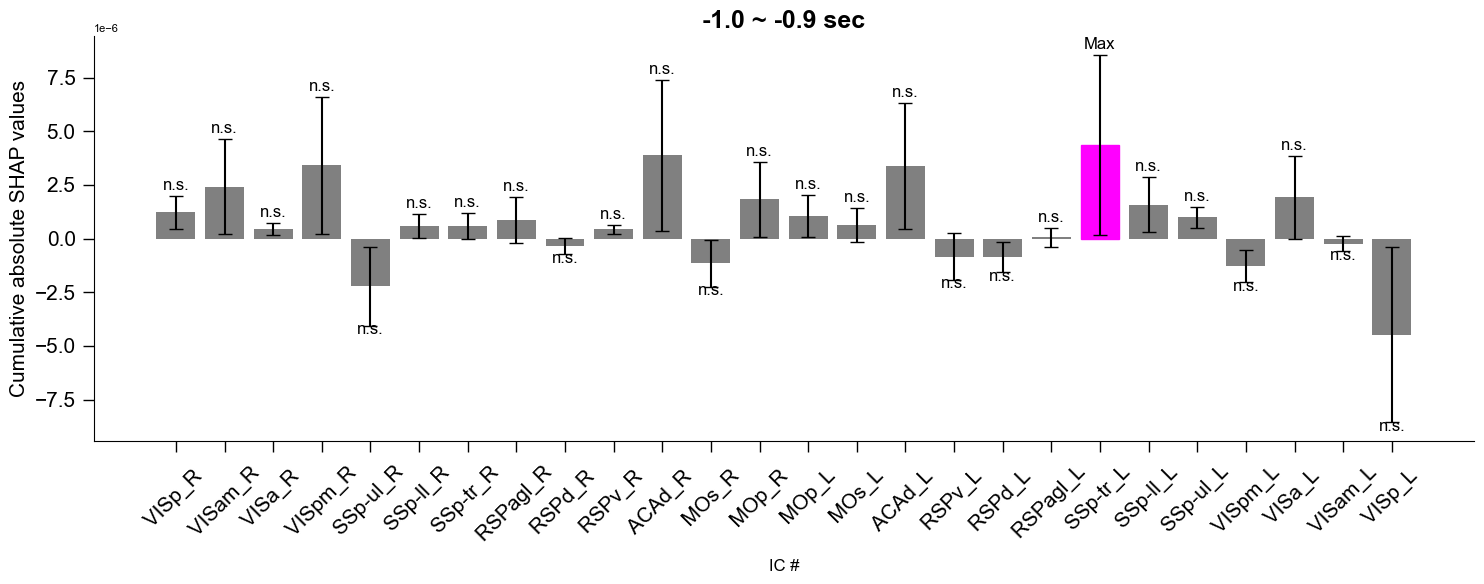

最も平均値が高いグループ: Group SSp-tr_L 
        Group          Mean           SEM   P-value  Corrected P-value  \
0    VISp_R    1.223240e-06  7.586842e-07  0.601508           1.000000   
1    VISam_R   2.424148e-06  2.205716e-06  0.916815           1.000000   
2    VISa_R    4.492733e-07  2.727927e-07  0.916815           1.000000   
3    VISpm_R   3.417589e-06  3.192883e-06  0.754023           1.000000   
4   SSp-ul_R  -2.228777e-06  1.824799e-06  0.047202           1.000000   
5   SSp-ll_R   5.854879e-07  5.527919e-07  0.601508           1.000000   
6   SSp-tr_R   5.852747e-07  6.031402e-07  0.601508           1.000000   
7   RSPagl_R   8.733487e-07  1.087555e-06  0.250592           1.000000   
8    RSPd_R   -3.528687e-07  3.870970e-07  0.250592           1.000000   
9    RSPv_R    4.288271e-07  1.954071e-07  0.916815           1.000000   
10   ACAd_R    3.885113e-06  3.515398e-06  0.916815           1.000000   
11    MOs_R   -1.157482e-06  1.074504e-06  0.117185           1.000000   
12    MO

In [82]:
make_bar_shap(roi_traces.transpose(1, 2, 0), start_frame=0, start_time=-1.0, end_frame=2, end_time=-0.9)

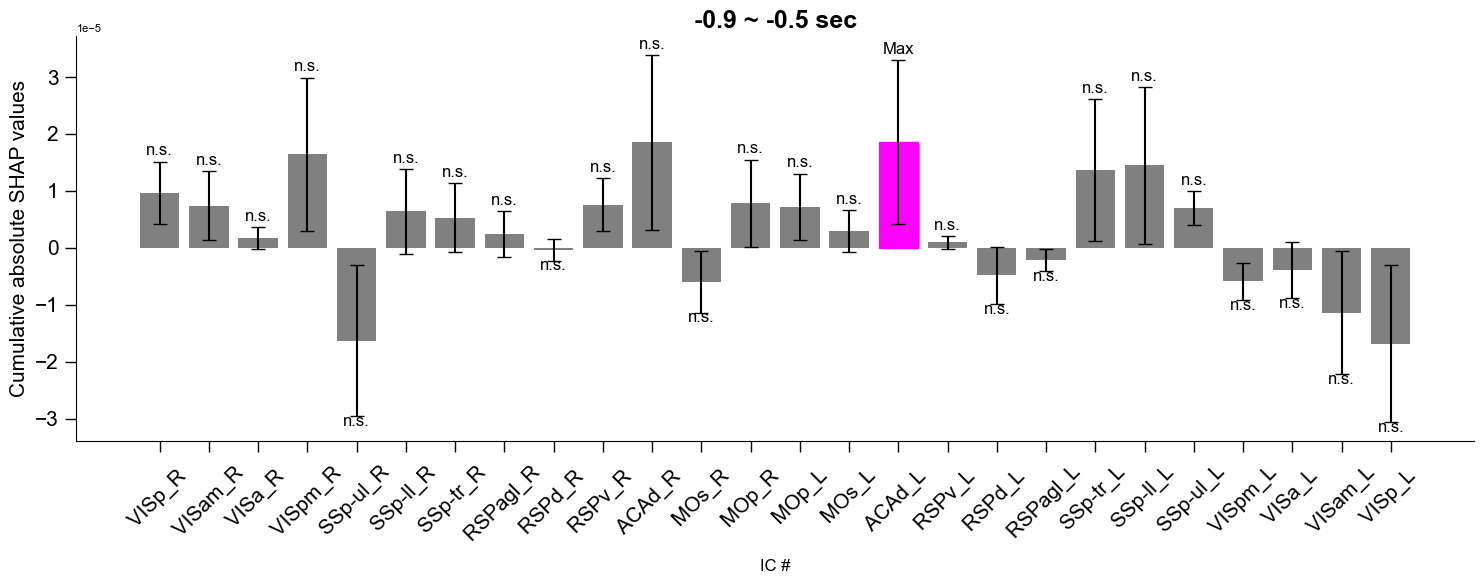

最も平均値が高いグループ: Group  ACAd_L  
        Group          Mean       SEM   P-value  Corrected P-value  \
0    VISp_R    9.658083e-06  0.000005  0.916815           1.000000   
1    VISam_R   7.419124e-06  0.000006  0.916815           1.000000   
2    VISa_R    1.670805e-06  0.000002  0.347208           1.000000   
3    VISpm_R   1.640091e-05  0.000014  0.916815           1.000000   
4   SSp-ul_R  -1.630151e-05  0.000013  0.075800           1.000000   
5   SSp-ll_R   6.455250e-06  0.000007  0.347208           1.000000   
6   SSp-tr_R   5.279560e-06  0.000006  0.464702           1.000000   
7   RSPagl_R   2.407487e-06  0.000004  0.347208           1.000000   
8    RSPd_R   -3.070577e-07  0.000002  0.250592           1.000000   
9    RSPv_R    7.610497e-06  0.000005  0.916815           1.000000   
10   ACAd_R    1.851786e-05  0.000015  0.916815           1.000000   
11    MOs_R   -5.976324e-06  0.000005  0.117185           1.000000   
12    MOp_R    7.864825e-06  0.000008  0.754023           1.

In [83]:
make_bar_shap(roi_traces.transpose(1, 2, 0), start_frame=2, start_time=-0.9, end_frame=10, end_time=-0.5)

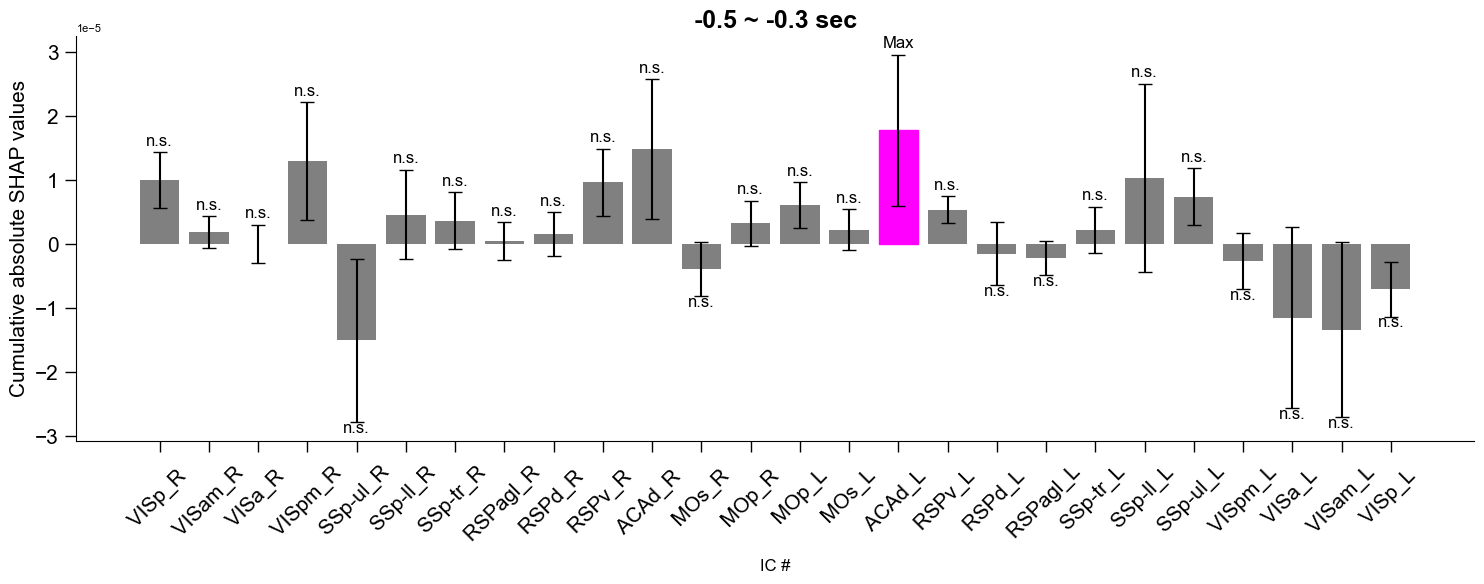

最も平均値が高いグループ: Group  ACAd_L  
        Group          Mean       SEM   P-value  Corrected P-value  \
0    VISp_R    1.003080e-05  0.000004  0.916815                1.0   
1    VISam_R   1.876101e-06  0.000002  0.347208                1.0   
2    VISa_R    4.201289e-08  0.000003  0.250592                1.0   
3    VISpm_R   1.306093e-05  0.000009  0.916815                1.0   
4   SSp-ul_R  -1.500551e-05  0.000013  0.117185                1.0   
5   SSp-ll_R   4.664725e-06  0.000007  0.174525                1.0   
6   SSp-tr_R   3.659331e-06  0.000004  0.174525                1.0   
7   RSPagl_R   5.065879e-07  0.000003  0.174525                1.0   
8    RSPd_R    1.608224e-06  0.000003  0.347208                1.0   
9    RSPv_R    9.668352e-06  0.000005  0.916815                1.0   
10   ACAd_R    1.482683e-05  0.000011  0.754023                1.0   
11    MOs_R   -3.798663e-06  0.000004  0.117185                1.0   
12    MOp_R    3.309646e-06  0.000004  0.250592             

In [84]:
make_bar_shap(roi_traces.transpose(1, 2, 0), start_frame=10, start_time=-0.5, end_frame=14, end_time=-0.3)

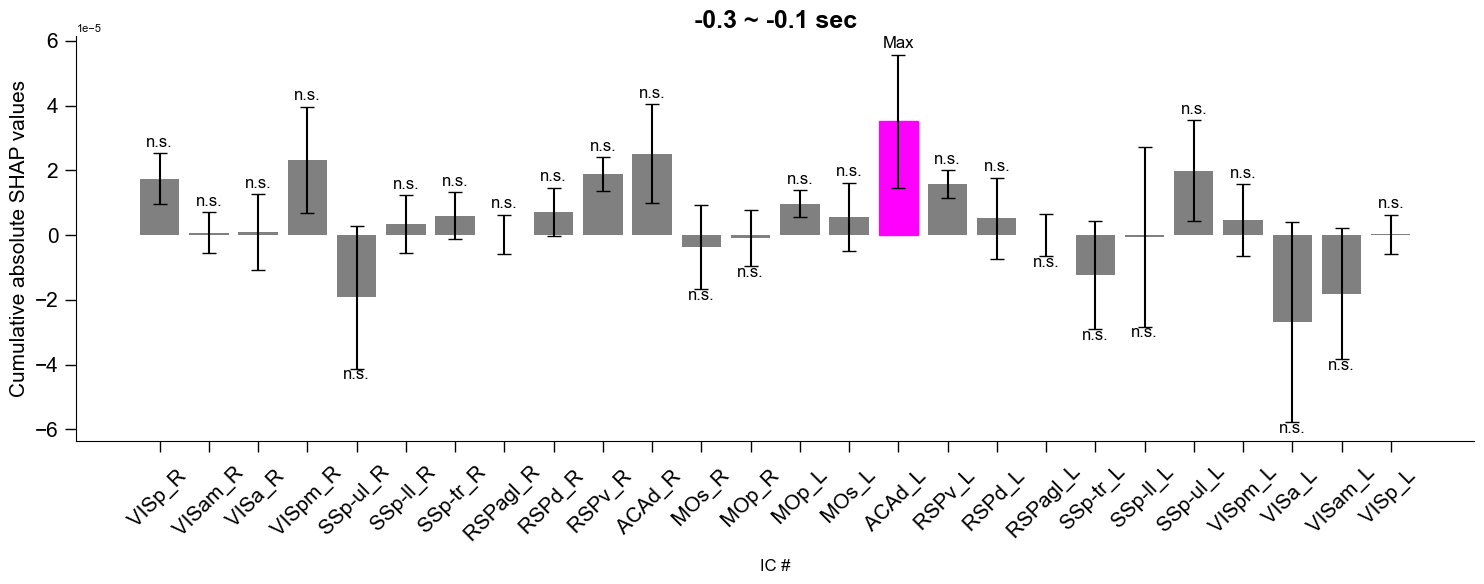

最も平均値が高いグループ: Group  ACAd_L  
        Group          Mean       SEM   P-value  Corrected P-value  \
0    VISp_R    1.737667e-05  0.000008  0.916815                1.0   
1    VISam_R   7.010633e-07  0.000006  0.347208                1.0   
2    VISa_R    8.101422e-07  0.000012  0.347208                1.0   
3    VISpm_R   2.319099e-05  0.000016  0.754023                1.0   
4   SSp-ul_R  -1.917841e-05  0.000022  0.117185                1.0   
5   SSp-ll_R   3.427349e-06  0.000009  0.174525                1.0   
6   SSp-tr_R   5.974661e-06  0.000007  0.601508                1.0   
7   RSPagl_R   1.582365e-07  0.000006  0.174525                1.0   
8    RSPd_R    7.176402e-06  0.000007  0.601508                1.0   
9    RSPv_R    1.888875e-05  0.000005  0.916815                1.0   
10   ACAd_R    2.513869e-05  0.000015  0.754023                1.0   
11    MOs_R   -3.676344e-06  0.000013  0.075800                1.0   
12    MOp_R   -9.724310e-07  0.000009  0.174525             

In [85]:
make_bar_shap(roi_traces.transpose(1, 2, 0), start_frame=14, start_time=-0.3, end_frame=18, end_time=-0.1)

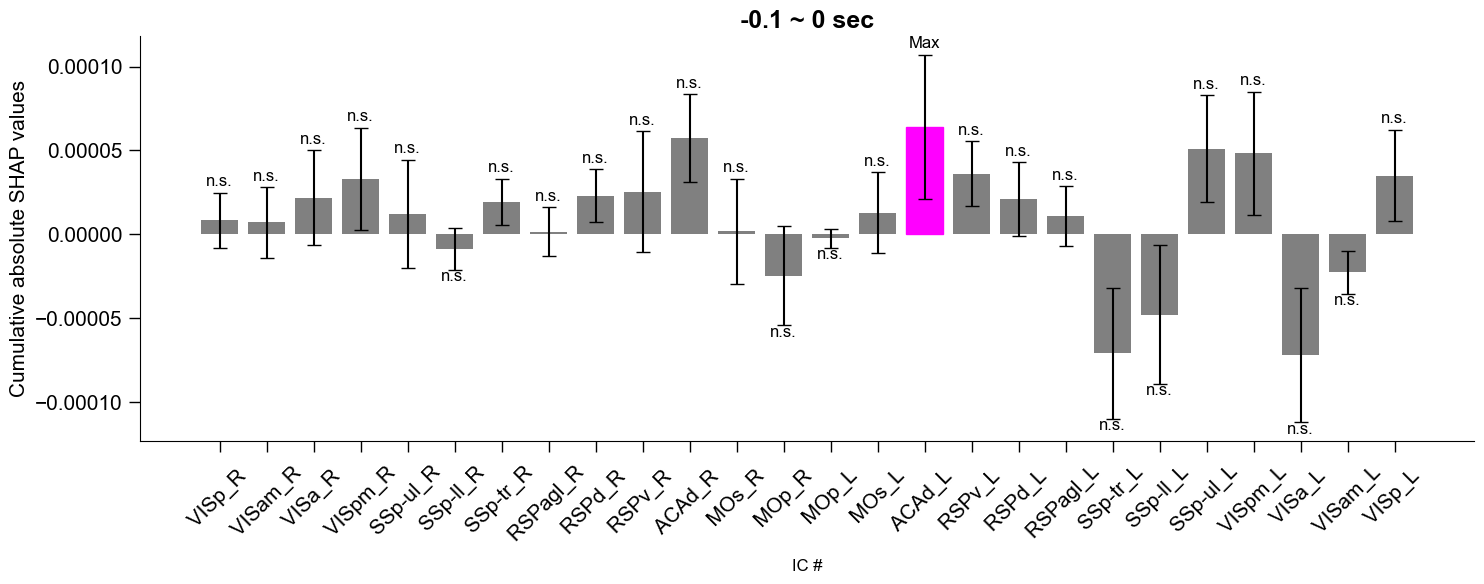

最も平均値が高いグループ: Group  ACAd_L  
        Group      Mean       SEM   P-value  Corrected P-value  Significant
0    VISp_R    0.000008  0.000016  0.250592                1.0        False
1    VISam_R   0.000007  0.000021  0.174525                1.0        False
2    VISa_R    0.000022  0.000028  0.464702                1.0        False
3    VISpm_R   0.000033  0.000030  0.916815                1.0        False
4   SSp-ul_R   0.000012  0.000032  0.347208                1.0        False
5   SSp-ll_R  -0.000009  0.000012  0.174525                1.0        False
6   SSp-tr_R   0.000019  0.000014  0.347208                1.0        False
7   RSPagl_R   0.000002  0.000015  0.174525                1.0        False
8    RSPd_R    0.000023  0.000016  0.464702                1.0        False
9    RSPv_R    0.000025  0.000036  0.347208                1.0        False
10   ACAd_R    0.000057  0.000026  0.754023                1.0        False
11    MOs_R    0.000002  0.000031  0.250592               

In [86]:
make_bar_shap(roi_traces.transpose(1, 2, 0), start_frame=18, start_time=-0.1, end_frame=21, end_time=0)

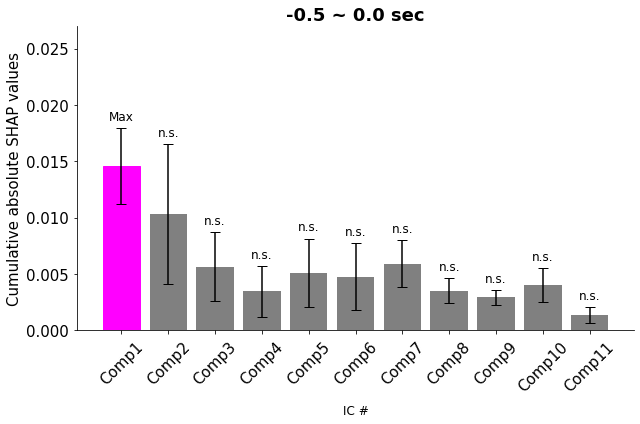

最も平均値が高いグループ: Group Comp1
     Group      Mean       SEM   P-value  Corrected P-value  Significant
0    Comp1  0.014560  0.003344  1.000000           1.000000        False
1    Comp2  0.010310  0.006204  0.512691           1.000000        False
2    Comp3  0.005647  0.003077  0.126630           0.759783        False
3    Comp4  0.003434  0.002240  0.049535           0.544881        False
4    Comp5  0.005073  0.003056  0.126630           0.759783        False
5    Comp6  0.004734  0.002969  0.126630           0.759783        False
6    Comp7  0.005906  0.002080  0.126630           0.759783        False
7    Comp8  0.003502  0.001113  0.049535           0.544881        False
8    Comp9  0.002909  0.000636  0.049535           0.544881        False
9   Comp10  0.004042  0.001504  0.049535           0.544881        False
10  Comp11  0.001343  0.000723  0.049535           0.544881        False
最重要ROIs
['Comp1', 'Comp2', 'Comp3', 'Comp4', 'Comp5', 'Comp6', 'Comp7', 'Comp8', 'Comp9', 'Comp10'

In [ ]:
make_bar_shap(mean_shaps, start_frame=0, start_time=-1, end_frame=11, end_time=0.0)

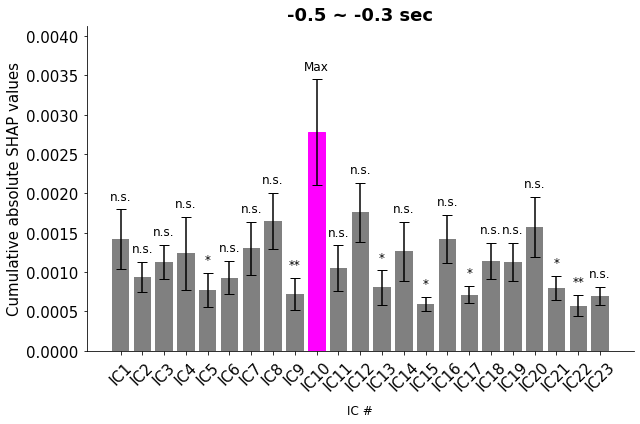

最も平均値が高いグループ: Group IC10
   Group      Mean       SEM   P-value  Corrected P-value  Significant
0    IC1  0.001421  0.000376  0.034866           0.383530        False
1    IC2  0.000934  0.000191  0.010177           0.132300        False
2    IC3  0.001128  0.000214  0.069931           0.495821        False
3    IC4  0.001237  0.000469  0.004508           0.063108        False
4    IC5  0.000772  0.000217  0.000877           0.018424         True
5    IC6  0.000927  0.000211  0.004140           0.062097        False
6    IC7  0.001303  0.000336  0.039801           0.398011        False
7    IC8  0.001651  0.000360  0.316898           0.950693        False
8    IC9  0.000724  0.000202  0.000289           0.006654         True
9   IC10  0.002779  0.000672  1.000000           1.000000        False
10  IC11  0.001051  0.000288  0.011881           0.142572        False
11  IC12  0.001761  0.000378  0.401720           0.950693        False
12  IC13  0.000805  0.000218  0.001552           0.0

In [33]:
make_bar_shap(mean_shaps, start_frame=0, start_time=-0.5, end_frame=4, end_time=-0.3)

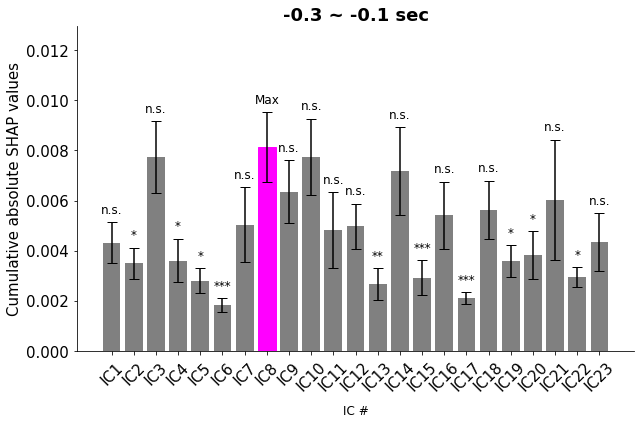

最も平均値が高いグループ: Group IC8
   Group      Mean       SEM   P-value  Corrected P-value  Significant
0    IC1  0.004323  0.000820  0.021490           0.193413        False
1    IC2  0.003487  0.000630  0.003194           0.047904         True
2    IC3  0.007730  0.001427  0.871069           1.000000        False
3    IC4  0.003604  0.000868  0.002677           0.045512         True
4    IC5  0.002800  0.000505  0.000722           0.013709         True
5    IC6  0.001830  0.000282  0.000007           0.000164         True
6    IC7  0.005040  0.001488  0.009409           0.103504        False
7    IC8  0.008130  0.001393  1.000000           1.000000        False
8    IC9  0.006357  0.001243  0.279251           1.000000        False
9   IC10  0.007746  0.001528  0.386708           1.000000        False
10  IC11  0.004819  0.001506  0.006294           0.075528        False
11  IC12  0.004965  0.000907  0.061978           0.433843        False
12  IC13  0.002659  0.000628  0.000260           0.00

In [34]:
make_bar_shap(mean_shaps, start_frame=4, start_time=-0.3, end_frame=8, end_time=-0.1)

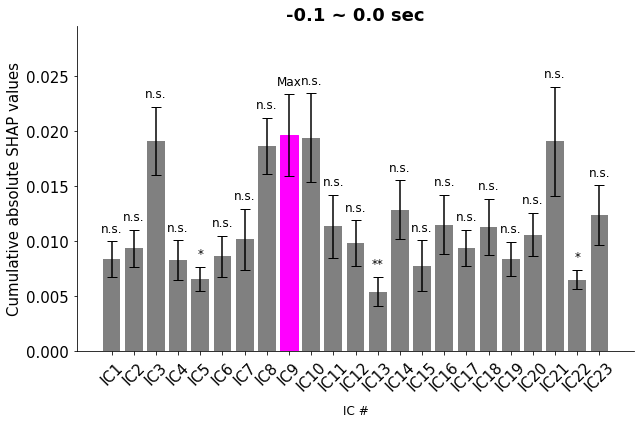

最も平均値が高いグループ: Group IC9
   Group      Mean       SEM   P-value  Corrected P-value  Significant
0    IC1  0.008348  0.001613  0.008694           0.165186        False
1    IC2  0.009351  0.001685  0.026548           0.345118        False
2    IC3  0.019108  0.003112  0.849818           1.000000        False
3    IC4  0.008239  0.001826  0.009409           0.169370        False
4    IC5  0.006510  0.001116  0.001170           0.025748         True
5    IC6  0.008604  0.001874  0.011881           0.201978        False
6    IC7  0.010127  0.002799  0.021490           0.322355        False
7    IC8  0.018638  0.002552  0.665159           1.000000        False
8    IC9  0.019623  0.003720  1.000000           1.000000        False
9   IC10  0.019406  0.004023  0.786775           1.000000        False
10  IC11  0.011324  0.002843  0.023074           0.323036        False
11  IC12  0.009800  0.002060  0.030464           0.365566        False
12  IC13  0.005369  0.001335  0.000321           0.00

In [35]:
make_bar_shap(mean_shaps, start_frame=8, start_time=-0.1, end_frame=11, end_time=0.0)